Notebook to deal with artifical condensate data AFTER initial per experiment analysis

TO POOL DATA FROM MULTIPLE EXPERIMENTS:

In [1]:
#requirements

import os
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from scipy.stats import fisher_exact, chi2_contingency

In [2]:
concat_folder = "/Volumes/mohrlab/mohrlabspace/Nora_Mohr/ANALYSIS/Condensates/250818-250903-250930-251001"

In [96]:
# load in all the data frames with the comparisons
df1_spots_dox = pd.read_csv("/Volumes/holtl02lab/holtl02labspace/Holt_Lab_Members/Nora_Holt/Live_Imaging_Other/250818_HeLa-2112-2537_2712-2714_5min_5h-TFH/Results_allTFH/output/all_data_spots_HeLa-2112_2712-2714_dox.csv")
df1_spots_un = pd.read_csv("/Volumes/holtl02lab/holtl02labspace/Holt_Lab_Members/Nora_Holt/Live_Imaging_Other/250818_HeLa-2112-2537_2712-2714_5min_5h-TFH/Results_allTFH/output/all_data_spots_HeLa-2537_2712-2714_dox.csv")
df2_spots_dox = pd.read_csv("/Volumes/holtl02lab/holtl02labspace/Holt_Lab_Members/Nora_Holt/Live_Imaging_Other/250903_HeLa-2112-2537_2712-2714_5min_TFH/Results_adjTFH/output/all_data_spots_HeLa-2112_2712-2714_Dox.csv")
df2_spots_un = pd.read_csv("/Volumes/holtl02lab/holtl02labspace/Holt_Lab_Members/Nora_Holt/Live_Imaging_Other/250903_HeLa-2112-2537_2712-2714_5min_TFH/Results_adjTFH/output/all_data_spots_HeLa-2537_2712-2714_Dox.csv")
df3_spots_dox = pd.read_csv("/Volumes/holtl02lab/holtl02labspace/Holt_Lab_Members/Nora_Holt/Live_Imaging_Other/250930_HeLa-2112-2537_2712-2714_4-5h-TFH/Results_StackReg/output/all_data_spots_HeLa-2112_2712-2714_Dox.csv")
df3_spots_un = pd.read_csv("/Volumes/holtl02lab/holtl02labspace/Holt_Lab_Members/Nora_Holt/Live_Imaging_Other/250930_HeLa-2112-2537_2712-2714_4-5h-TFH/Results_StackReg/output/all_data_spots_HeLa-2537_2712-2714_Dox.csv")
df4_spots_dox = pd.read_csv("/Volumes/holtl02lab/holtl02labspace/Holt_Lab_Members/Nora_Holt/Live_Imaging_Other/251001_HeLa-2112-2537_2712-2714_5min_4h-TFH/Results_StackReg_-6/output/all_data_spots_HeLa-2112_2712-2714_Dox.csv")
df4_spots_un = pd.read_csv("/Volumes/holtl02lab/holtl02labspace/Holt_Lab_Members/Nora_Holt/Live_Imaging_Other/251001_HeLa-2112-2537_2712-2714_5min_4h-TFH/Results_StackReg_-6/output/all_data_spots_HeLa-2537_2712-2714_Dox.csv")

df1_tracks_dox = pd.read_csv("/Volumes/holtl02lab/holtl02labspace/Holt_Lab_Members/Nora_Holt/Live_Imaging_Other/250818_HeLa-2112-2537_2712-2714_5min_5h-TFH/Results_allTFH/output/all_data_tracks_HeLa-2112_2712-2714_dox.csv")
df1_tracks_un = pd.read_csv("/Volumes/holtl02lab/holtl02labspace/Holt_Lab_Members/Nora_Holt/Live_Imaging_Other/250818_HeLa-2112-2537_2712-2714_5min_5h-TFH/Results_allTFH/output/all_data_tracks_HeLa-2537_2712-2714_dox.csv")
df2_tracks_dox = pd.read_csv("/Volumes/holtl02lab/holtl02labspace/Holt_Lab_Members/Nora_Holt/Live_Imaging_Other/250903_HeLa-2112-2537_2712-2714_5min_TFH/Results_adjTFH/output/all_data_tracks_HeLa-2112_2712-2714_Dox.csv")
df2_tracks_un = pd.read_csv("/Volumes/holtl02lab/holtl02labspace/Holt_Lab_Members/Nora_Holt/Live_Imaging_Other/250903_HeLa-2112-2537_2712-2714_5min_TFH/Results_adjTFH/output/all_data_tracks_HeLa-2537_2712-2714_Dox.csv")
df3_tracks_dox = pd.read_csv("/Volumes/holtl02lab/holtl02labspace/Holt_Lab_Members/Nora_Holt/Live_Imaging_Other/250930_HeLa-2112-2537_2712-2714_4-5h-TFH/Results_StackReg/output/all_data_tracks_HeLa-2112_2712-2714_Dox.csv")
df3_tracks_un = pd.read_csv("/Volumes/holtl02lab/holtl02labspace/Holt_Lab_Members/Nora_Holt/Live_Imaging_Other/250930_HeLa-2112-2537_2712-2714_4-5h-TFH/Results_StackReg/output/all_data_tracks_HeLa-2537_2712-2714_Dox.csv")
df4_tracks_dox = pd.read_csv("/Volumes/holtl02lab/holtl02labspace/Holt_Lab_Members/Nora_Holt/Live_Imaging_Other/251001_HeLa-2112-2537_2712-2714_5min_4h-TFH/Results_StackReg_-6/output/all_data_tracks_HeLa-2112_2712-2714_Dox.csv")
df4_tracks_un = pd.read_csv("/Volumes/holtl02lab/holtl02labspace/Holt_Lab_Members/Nora_Holt/Live_Imaging_Other/251001_HeLa-2112-2537_2712-2714_5min_4h-TFH/Results_StackReg_-6/output/all_data_tracks_HeLa-2537_2712-2714_Dox.csv")

# Concatenate by group and type
all_data_spots_Dox = pd.concat([df1_spots_dox, df2_spots_dox, df3_spots_dox, df4_spots_dox], ignore_index=True)
all_data_spots_Untreated = pd.concat([df1_spots_un, df2_spots_un, df3_spots_un, df4_spots_un], ignore_index=True)
all_data_tracks_Dox = pd.concat([df1_tracks_dox, df2_tracks_dox, df3_tracks_dox, df4_tracks_dox], ignore_index=True)
all_data_tracks_Untreated = pd.concat([df1_tracks_un, df2_tracks_un, df3_tracks_un, df4_tracks_un], ignore_index=True)

# Save to CSV
all_data_spots_Dox.to_csv(os.path.join(concat_folder, f"all_data_spots_Dox_combined.csv"), index=False)
all_data_spots_Untreated.to_csv(os.path.join(concat_folder, f"all_data_spots_Untreated_combined.csv"), index=False)
all_data_tracks_Dox.to_csv(os.path.join(concat_folder, f"all_data_tracks_Dox_combined.csv"), index=False)
all_data_tracks_Untreated.to_csv(os.path.join(concat_folder, f"all_data_tracks_Untreated_combined.csv"), index=False)

In [3]:
# Read back in, if already exists

all_data_spots_Dox = pd.read_csv(os.path.join(concat_folder, f"all_data_spots_Dox_combined.csv"), header = 0)
all_data_spots_Untreated = pd.read_csv(os.path.join(concat_folder, f"all_data_spots_Untreated_combined.csv"), header = 0)
all_data_tracks_Dox = pd.read_csv(os.path.join(concat_folder, f"all_data_tracks_Dox_combined.csv"), header = 0)
all_data_tracks_Untreated = pd.read_csv(os.path.join(concat_folder, f"all_data_tracks_Untreated_combined.csv"), header = 0)

In [4]:
# --- Parameters ---
pixel_size = 0.1833       # µm/pixel
frame_interval = 5 * 60    # seconds/frame
max_steps = 10             # steps for truncated diffusion

# --- List of groups and their edges DataFrames ---
groups = {
    "Dox": all_data_spots_Dox,
    "Untreated": all_data_spots_Untreated
}

# --- Assign group colors ---
color_map = {
    "Dox": "#7f32bd",        # deep purple
    "Untreated": "#aa88ff"   # bright purple
}

def compute_diffusion(spots_df, pixel_size, frame_interval):
    """
    Compute full diffusion coefficients (µm²/s) per track.
    Returns DataFrame with TRACK_ID, D_um2_s, num_steps, and start/end positions.
    """
    spots = spots_df.sort_values(['unique_name', 'FRAME']).copy()
    spots['dx'] = spots.groupby('unique_name')['POSITION_X'].diff() * pixel_size
    spots['dy'] = spots.groupby('unique_name')['POSITION_Y'].diff() * pixel_size
    spots['dr2'] = spots['dx']**2 + spots['dy']**2
    spots['dt'] = spots.groupby('unique_name')['FRAME'].diff() * frame_interval

    results = []
    for unique_name, group in spots.groupby('unique_name'):
        step1 = group[group['dt'] == frame_interval]
        num_steps = len(step1)
        if num_steps == 0:
            continue
        msd_1 = step1['dr2'].mean()
        D = msd_1 / (4 * frame_interval)

        # Track start and end
        x_start = group['POSITION_X'].iloc[0] * pixel_size
        y_start = group['POSITION_Y'].iloc[0] * pixel_size
        x_end = group['POSITION_X'].iloc[-1] * pixel_size
        y_end = group['POSITION_Y'].iloc[-1] * pixel_size
        frame_start = group['FRAME'].iloc[0]
        frame_end = group['FRAME'].iloc[-1]

        # Mean intensity across full track
        mean_intensity = group['MEAN_INTENSITY_CH1'].mean()

        # Carry the first TRACK_ID in this unique_name
        track_id = group['TRACK_ID'].iloc[0]

        results.append({
            'unique_name': unique_name,
            'TRACK_ID': track_id,
            'D_um2_s': D,
            'num_steps': num_steps,
            'x_start_full': x_start,
            'y_start_full': y_start,
            'x_end_full': x_end,
            'y_end_full': y_end,
            'frame_start_full': frame_start,
            'frame_end_full': frame_end,
            'mean_track_intensity_full': mean_intensity
        })
    return pd.DataFrame(results)


def filter_and_truncate_trajectories(spots_df, pixel_size, frame_interval, max_steps=max_steps):
    """
    Keep trajectories with >= (max_steps + 1) positions,
    truncate to first (max_steps + 1) positions (10 steps = 11 positions),
    and compute truncated diffusion and start/end positions.
    """
    spots = spots_df.sort_values(['unique_name', 'FRAME']).copy()
    spots['dx'] = spots.groupby('unique_name')['POSITION_X'].diff() * pixel_size
    spots['dy'] = spots.groupby('unique_name')['POSITION_Y'].diff() * pixel_size
    spots['dr2'] = spots['dx']**2 + spots['dy']**2
    spots['dt'] = spots.groupby('unique_name')['FRAME'].diff() * frame_interval

    col_trunc_s = f'D_truncated_{max_steps}_steps_um2_s'
    results = []

    for unique_name, group in spots.groupby('unique_name'):
        if len(group) < max_steps + 1:
            continue
        truncated = group.iloc[:max_steps + 1]
        step1_trunc = truncated[truncated['dt'] == frame_interval]
        if len(step1_trunc) == 0:
            continue
        msd_1 = step1_trunc['dr2'].mean()
        D_trunc = msd_1 / (4 * frame_interval)

        # Track start and end (truncated)
        x_start = truncated['POSITION_X'].iloc[0] * pixel_size
        y_start = truncated['POSITION_Y'].iloc[0] * pixel_size
        x_end = truncated['POSITION_X'].iloc[-1] * pixel_size
        y_end = truncated['POSITION_Y'].iloc[-1] * pixel_size
        frame_start = truncated['FRAME'].iloc[0]
        frame_end = truncated['FRAME'].iloc[-1]

        # Mean intensity across truncated segment
        mean_intensity = truncated['MEAN_INTENSITY_CH1'].mean()

        # Carry first TRACK_ID
        track_id = truncated['TRACK_ID'].iloc[0]

        results.append({
            'unique_name': unique_name,
            'TRACK_ID': track_id,
            col_trunc_s: D_trunc,
            'num_steps_trunc': max_steps,
            'x_start_trunc': x_start,
            'y_start_trunc': y_start,
            'x_end_trunc': x_end,
            'y_end_trunc': y_end,
            'frame_start_trunc': frame_start,
            'frame_end_trunc': frame_end,
            'mean_track_intensity_trunc': mean_intensity
        })
    return pd.DataFrame(results)



# Loop through groups, compute diffusion, truncated diffusion, add min units, and save CSV
# --- Run for all groups ---
for group_name, spots_df in groups.items():
    spots_df.columns = spots_df.columns.str.strip()

    # Compute full and truncated diffusion
    diffusion_full = compute_diffusion(spots_df, pixel_size, frame_interval)
    diffusion_trunc = filter_and_truncate_trajectories(spots_df, pixel_size, frame_interval, max_steps=max_steps)

    # Merge
    diffusion_combined = pd.merge(diffusion_full, diffusion_trunc, on='unique_name', how='left')
    
    # Add µm²/min equivalents
    diffusion_combined['D_um2_min'] = diffusion_combined['D_um2_s'] * 60
    col_trunc_s = f'D_truncated_{max_steps}_steps_um2_s'
    col_trunc_min = f'D_truncated_{max_steps}_steps_um2_min'
    if col_trunc_s in diffusion_combined.columns:
        diffusion_combined[col_trunc_min] = diffusion_combined[col_trunc_s] * 60

    # Reorder columns
    columns_order = [
        'unique_name',
        'TRACK_ID',
        'num_steps', 'num_steps_trunc',
        'D_um2_s', 'D_um2_min', col_trunc_s, col_trunc_min,
        'mean_track_intensity_full', 'mean_track_intensity_trunc',
        'x_start_full', 'y_start_full', 'x_end_full', 'y_end_full', 
        'frame_start_full', 'frame_end_full',
        'x_start_trunc', 'y_start_trunc', 'x_end_trunc', 'y_end_trunc', 
        'frame_start_trunc', 'frame_end_trunc'
    ]
    diffusion_combined = diffusion_combined[[c for c in columns_order if c in diffusion_combined.columns]]

    # Save
    output_csv_path = os.path.join(concat_folder, f"diffusion_calculations_{group_name}.csv")
    diffusion_combined.to_csv(output_csv_path, index=False)
    print(f"✅ Saved diffusion CSV for {group_name}: {output_csv_path}")


✅ Saved diffusion CSV for Dox: /Volumes/mohrlab/mohrlabspace/Nora_Mohr/ANALYSIS/Condensates/250818-250903-250930-251001/diffusion_calculations_Dox.csv
✅ Saved diffusion CSV for Untreated: /Volumes/mohrlab/mohrlabspace/Nora_Mohr/ANALYSIS/Condensates/250818-250903-250930-251001/diffusion_calculations_Untreated.csv


Loaded groups: ['Dox' 'Untreated']
Combined shape: (14593, 22)


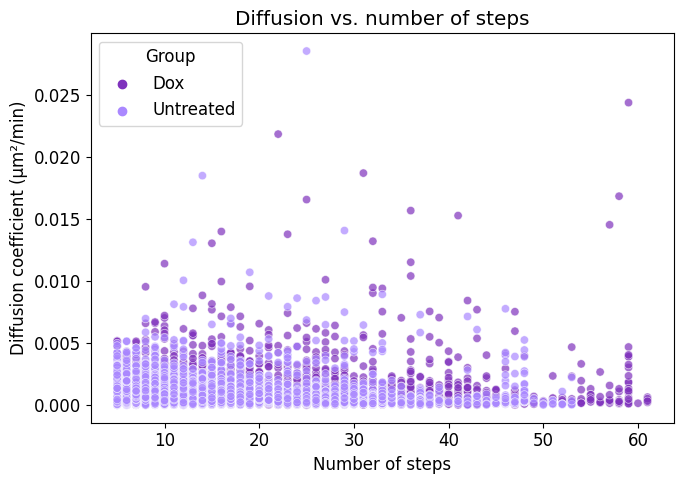

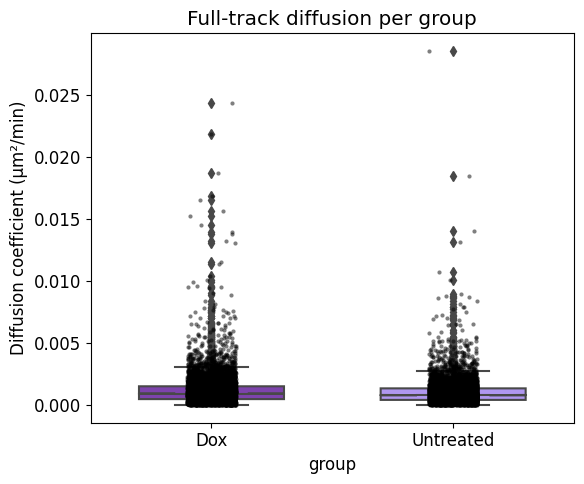

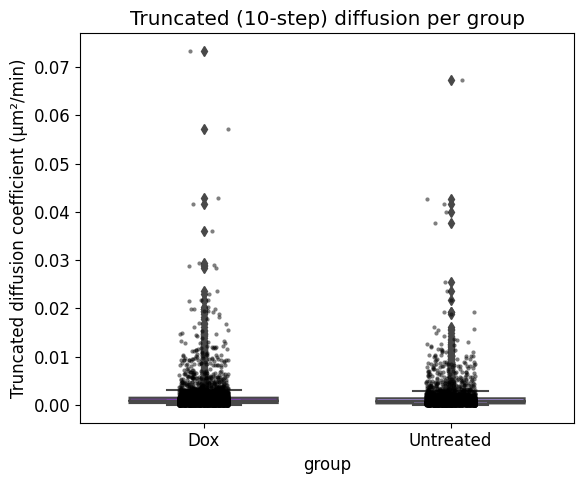

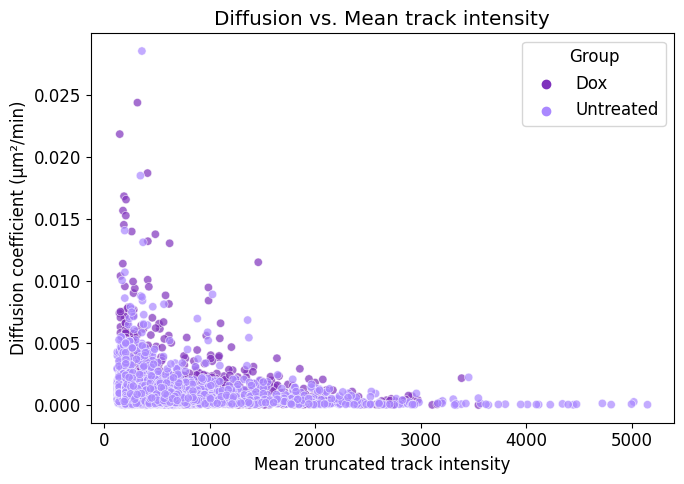

In [5]:
#Plot the diffusion coefficient from the above cell

# --- SETTINGS ---
input_dir = concat_folder  # same directory where your diffusion CSVs are saved
pattern = r"diffusion_calculations_(.+)\.csv"  # captures the group name
plt.rcParams.update({'font.size': 12})

# --- LOAD ALL GROUP FILES ---
all_data = []
for file in os.listdir(input_dir):
    match = re.match(pattern, file)
    if match:
        group_name = match.group(1)
        df = pd.read_csv(os.path.join(input_dir, file))
        df["group"] = group_name
        all_data.append(df)

# Combine into single dataframe
diffusion_combined = pd.concat(all_data, ignore_index=True)

print("Loaded groups:", diffusion_combined["group"].unique())
print("Combined shape:", diffusion_combined.shape)

# --- 1️⃣ Scatter plot: D_um2_min vs. num_steps ---
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=diffusion_combined,
    x="num_steps",
    y="D_um2_min",
    hue="group",
    palette=color_map,
    alpha=0.7
)
plt.xlabel("Number of steps")
plt.ylabel("Diffusion coefficient (µm²/min)")
plt.title("Diffusion vs. number of steps")
plt.legend(title="Group")
plt.tight_layout()
plt.savefig(os.path.join(concat_folder, "num-steps_vs_D-um2.png"), bbox_inches="tight", dpi=300)
plt.show()

# --- 2️⃣ Boxplot: full diffusion ---
plt.figure(figsize=(6, 5))
sns.boxplot(
    data=diffusion_combined,
    x="group",
    y="D_um2_min",
    palette=color_map,
    notch=True,
    width=0.6
)
sns.stripplot(
    data=diffusion_combined,
    x="group",
    y="D_um2_min",
    color="black",
    size=3,
    jitter=True,
    alpha=0.5
)
plt.ylabel("Diffusion coefficient (µm²/min)")
plt.title("Full-track diffusion per group")
plt.tight_layout()
plt.savefig(os.path.join(concat_folder, "D-um2_full_per-group.png"), bbox_inches="tight", dpi=300)
plt.show()

# --- 3️⃣ Boxplot: truncated diffusion ---
plt.figure(figsize=(6, 5))
sns.boxplot(
    data=diffusion_combined,
    x="group",
    y=col_trunc_min,
    palette=color_map,
    notch=True,
    width=0.6
)
sns.stripplot(
    data=diffusion_combined,
    x="group",
    y=col_trunc_min,
    color="black",
    size=3,
    jitter=True,
    alpha=0.5
)
plt.ylabel("Truncated diffusion coefficient (µm²/min)")
plt.title("Truncated (10-step) diffusion per group")
plt.tight_layout()
plt.savefig(os.path.join(concat_folder, "D-um2_trunc_per-group.png"), bbox_inches="tight", dpi=300)
plt.show()

# --- 4️⃣ Scatter plot: D_um2_min vs. Mean Track Intensity Truncated ---
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=diffusion_combined,
    x="mean_track_intensity_trunc",
    y="D_um2_min",
    hue="group",
    palette=color_map,
    alpha=0.7
)
plt.xlabel("Mean truncated track intensity")
plt.ylabel("Diffusion coefficient (µm²/min)")
plt.title("Diffusion vs. Mean track intensity")
plt.legend(title="Group")
plt.tight_layout()
plt.savefig(os.path.join(concat_folder, "mean-intensity_vs_D-um2.png"), bbox_inches="tight", dpi=300)
plt.show()

In [6]:
# --- Filter out rows with missing TRACK_INDEX ---
tracks_dox_filtered = all_data_tracks_Dox.dropna(subset=['TRACK_INDEX'])
tracks_un_filtered = all_data_tracks_Untreated.dropna(subset=['TRACK_INDEX'])

# --- Conditionally convert TRACK_START from frames to minutes ---
# THIS IS ONLY GOOD FOR SHORT TIME LENGTH MOVIES (~1HR)
tracks_dox_filtered['TRACK_START'] = tracks_dox_filtered['TRACK_START'].apply(
    lambda x: np.floor(x / 60) if x >= 100 else x
)
tracks_un_filtered['TRACK_START'] = tracks_un_filtered['TRACK_START'].apply(
    lambda x: np.floor(x / 60) if x >= 100 else x
)


/var/folders/tn/mq6hmrjj03j8dxy2x5lk_1qw0000gn/T/ipykernel_73801/1424200083.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tracks_dox_filtered['TRACK_START'] = tracks_dox_filtered['TRACK_START'].apply(
/var/folders/tn/mq6hmrjj03j8dxy2x5lk_1qw0000gn/T/ipykernel_73801/1424200083.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tracks_un_filtered['TRACK_START'] = tracks_un_filtered['TRACK_START'].apply(


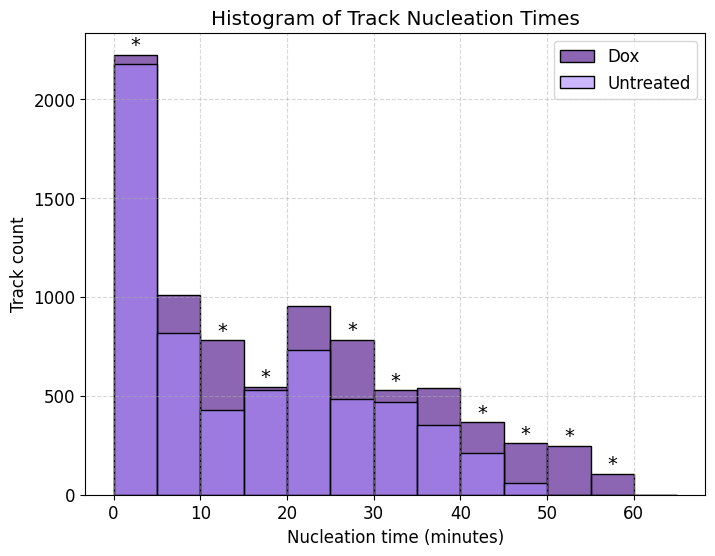

/var/folders/tn/mq6hmrjj03j8dxy2x5lk_1qw0000gn/T/ipykernel_73801/3528080926.py:62: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(tracks_dox_filtered['TRACK_START'], color='#40007F', label='Dox', shade=True, alpha=0.5)
/var/folders/tn/mq6hmrjj03j8dxy2x5lk_1qw0000gn/T/ipykernel_73801/3528080926.py:65: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(tracks_un_filtered['TRACK_START'], color='#aa88ff', label='Untreated', shade=True, alpha=0.5)


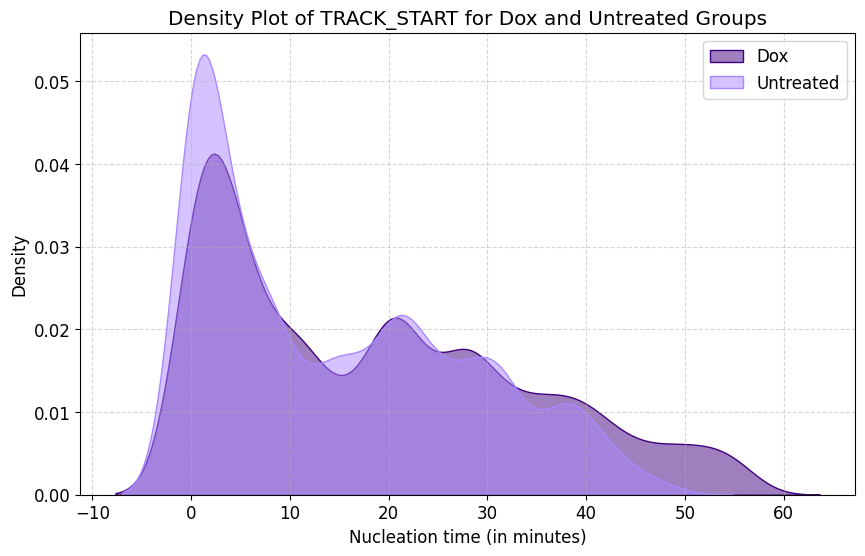

/var/folders/tn/mq6hmrjj03j8dxy2x5lk_1qw0000gn/T/ipykernel_73801/3528080926.py:80: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tracks_dox_filtered["Group"] = "Dox"
/var/folders/tn/mq6hmrjj03j8dxy2x5lk_1qw0000gn/T/ipykernel_73801/3528080926.py:81: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tracks_un_filtered["Group"] = "Untreated"
/var/folders/tn/mq6hmrjj03j8dxy2x5lk_1qw0000gn/T/ipykernel_73801/3528080926.py:97: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(


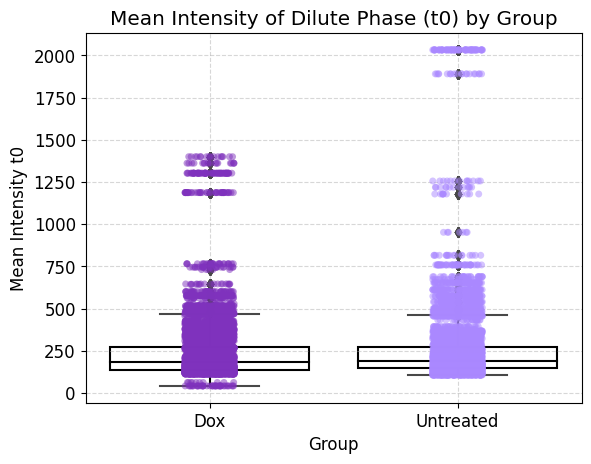

In [7]:
# --- Define 5-minute bins (or whatever minute) ---
bin_width = 5
max_bin = max(tracks_dox_filtered['TRACK_START'].max(), tracks_un_filtered['TRACK_START'].max()) + bin_width
bins = np.arange(0, max_bin + bin_width, bin_width)

# --- Compute histogram counts ---
dox_counts, _ = np.histogram(tracks_dox_filtered['TRACK_START'], bins=bins)
un_counts, _ = np.histogram(tracks_un_filtered['TRACK_START'], bins=bins)

p_values = []
for d_count, u_count in zip(dox_counts, un_counts):
    # 2x2 contingency table: Dox vs Untreated in this bin vs all other bins
    table = [[d_count, u_count],
             [sum(dox_counts) - d_count, sum(un_counts) - u_count]]
    
    # Choose test based on counts
    if d_count + u_count < 20:
        _, p = fisher_exact(table)
    else:
        _, p, _, _ = chi2_contingency(table)
    
    p_values.append(p)

# --- Create DataFrame for histogram output ---
histogram_df = pd.DataFrame({
    "TIME_BIN_START": bins[:-1],
    "NUCLEATION_EVENTS_Dox": dox_counts,
    "NUCLEATION_EVENTS_Untreated": un_counts
})

# Save histogram data to CSV
histogram_df.to_csv(os.path.join(concat_folder, "nucleation_histogram_data.csv"), index=False)

# --- Plotting ---
plt.figure(figsize=(8, 6))

sns.histplot(tracks_dox_filtered['TRACK_START'], bins=bins, color='#40007F', label='Dox', alpha=0.6, kde=False, stat='count')
sns.histplot(tracks_un_filtered['TRACK_START'], bins=bins, color='#aa88ff', label='Untreated', alpha=0.6, kde=False, stat='count')

# Add stars to bins with significant p-values
for i, (bin_start, p) in enumerate(zip(bins[:-1], p_values)):
    if p < 0.05:
        # Get the max bar height at this bin to position the star
        max_count = max(dox_counts[i], un_counts[i])
        # Adjust star position slightly above the bar
        plt.text(bin_start + bin_width/2, max_count + 0.5, '*', ha='center', va='bottom', fontsize=14, color='black')

plt.xlabel("Nucleation time (minutes)")
plt.ylabel("Track count")
plt.title("Histogram of Track Nucleation Times")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

# Save the figure
plt.savefig(os.path.join(concat_folder, "nucleation_histogram_with_stars.png"), bbox_inches="tight", dpi=300)
plt.show()

# Plot the density of 'TRACK_START' for Dox and Untreated groups
plt.figure(figsize=(10, 6))

# Plot density for Dox group
sns.kdeplot(tracks_dox_filtered['TRACK_START'], color='#40007F', label='Dox', shade=True, alpha=0.5)

# Plot density for Untreated group
sns.kdeplot(tracks_un_filtered['TRACK_START'], color='#aa88ff', label='Untreated', shade=True, alpha=0.5)

# Labels and title
plt.xlabel("Nucleation time (in minutes)")
plt.ylabel("Density")
plt.title("Density Plot of TRACK_START for Dox and Untreated Groups")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.savefig(f"{concat_folder}/nucleation_density.png", bbox_inches="tight", dpi=300)
# Show the plot
plt.show()


# Combine the two filtered DataFrames and add a group column
tracks_dox_filtered["Group"] = "Dox"
tracks_un_filtered["Group"] = "Untreated"
df_combined = pd.concat([tracks_dox_filtered, tracks_un_filtered])

# Boxplot
sns.boxplot(
    data=df_combined,
    x="Group",
    y="Mean_Intensity_t0",
    palette=color_map,
    showcaps=True,
    boxprops={"facecolor": "none", "edgecolor": "black"},
    whiskerprops={"color": "black"},
    medianprops={"color": "black"}
)

# Overlay points
sns.stripplot(
    data=df_combined,
    x="Group",
    y="Mean_Intensity_t0",
    jitter=True,
    alpha=0.5,
    palette=color_map
)

# Labels and title
plt.ylabel("Mean Intensity t0")
plt.title("Mean Intensity of Dilute Phase (t0) by Group")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


In [8]:
from scipy.stats import ks_2samp

stat, p = ks_2samp(tracks_dox_filtered['TRACK_START'], tracks_un_filtered['TRACK_START'])
print(f"KS test p-value = {p:.4f}")

KS test p-value = 0.0000


Unique cells present at FRAME 32: 2332
Unique cells present at FRAME 32: 1980


/var/folders/tn/mq6hmrjj03j8dxy2x5lk_1qw0000gn/T/ipykernel_73801/2178999879.py:60: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(


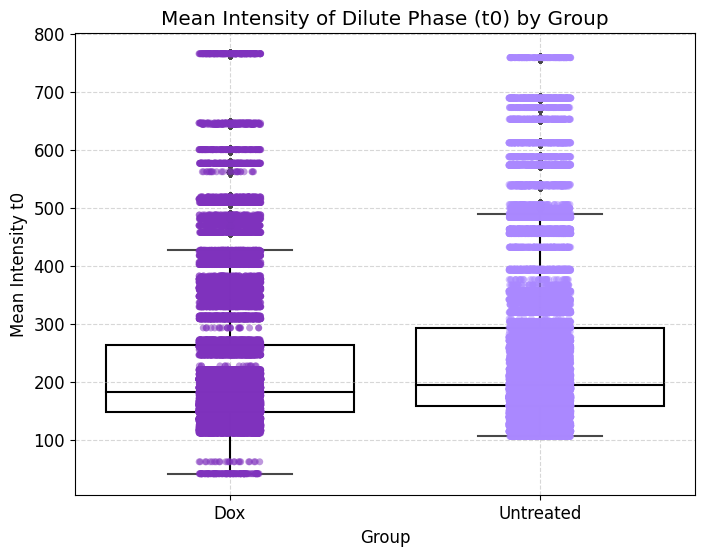

In [9]:
# --- Settings ---
first = 0
lst = 32  # last frame of interest
max_intensity = 800

# --- Subset for cells present at last frame (lst) ---
def get_present_at_end(df_spots, lst):
    unique_names_lst = df_spots[df_spots['FRAME'] == lst]['unique_name']
    print(f"Unique cells present at FRAME {lst}: {unique_names_lst.nunique()}")
    return df_spots[df_spots['unique_name'].isin(unique_names_lst)]

# --- Processing function ---
def process_and_save_subset(df_subset, group_name, first, lst, concat_folder, max_intensity=max_intensity):
    # Filter by frame range
    df_subset = df_subset[(df_subset["FRAME"] >= (first - 1)) & (df_subset["FRAME"] <= lst)]
    
    # Filter by max intensity at t0
    if max_intensity is not None:
        df_subset = df_subset[df_subset["Mean_Intensity_t0"] <= max_intensity]
    
    # Add COUNT column
    df_subset["COUNT"] = df_subset["FRAME"] - first

    # Save to CSV
    filename = f"subset_spots_{group_name}_{first}-{lst}.csv"
    output_path = os.path.join(concat_folder, filename)
    df_subset.to_csv(output_path, index=False)

    return df_subset

# --- Apply to both Dox and Untreated ---
subset_spots_dox = get_present_at_end(all_data_spots_Dox, lst)
subset_spots_un = get_present_at_end(all_data_spots_Untreated, lst)

# Filter, count, save
df_range_dox = process_and_save_subset(subset_spots_dox, "Dox", first, lst, concat_folder)
df_range_un = process_and_save_subset(subset_spots_un, "Untreated", first, lst, concat_folder)

#sanity check for filtration:
plt.figure(figsize=(8, 6))

# Combine the two filtered DataFrames and add a group column
df_range_dox["Group"] = "Dox"
df_range_un["Group"] = "Untreated"
df_combined = pd.concat([df_range_dox, df_range_un])

# Boxplot
sns.boxplot(
    data=df_combined,
    x="Group",
    y="Mean_Intensity_t0",
    palette=color_map,
    showcaps=True,
    boxprops={"facecolor": "none", "edgecolor": "black"},
    whiskerprops={"color": "black"},
    medianprops={"color": "black"}
)

# Overlay points
sns.stripplot(
    data=df_combined,
    x="Group",
    y="Mean_Intensity_t0",
    jitter=True,
    alpha=0.5,
    palette=color_map
)

# Labels and title
plt.ylabel("Mean Intensity t0")
plt.title("Mean Intensity of Dilute Phase (t0) by Group")
plt.grid(True, linestyle="--", alpha=0.5)

# Save and show
plt.savefig(f"{concat_folder}/mean_intensity_t0_boxplot.png", bbox_inches="tight", dpi=300)
plt.show()


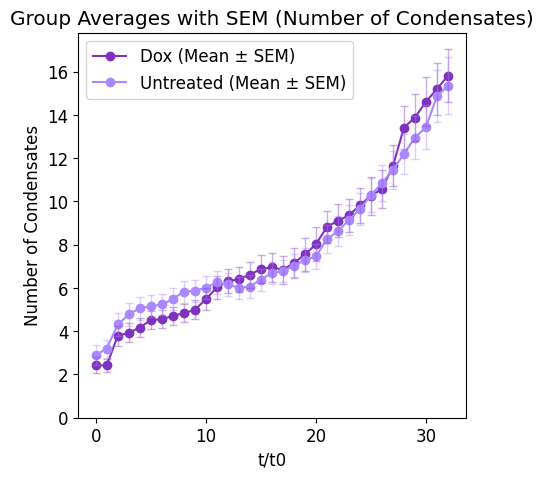

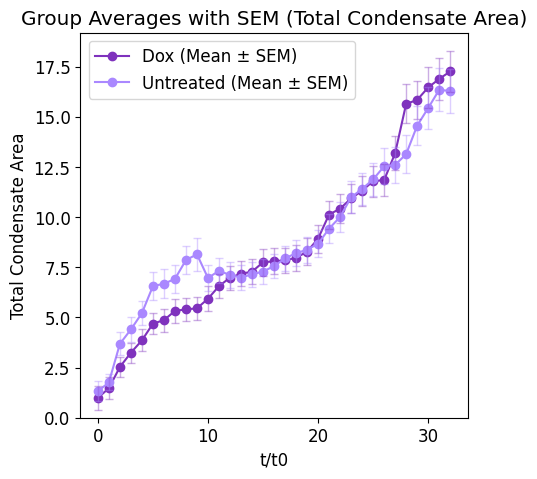

Stats file saved: /Volumes/mohrlab/mohrlabspace/Nora_Mohr/ANALYSIS/Condensates/250818-250903-250930-251001/stats_0-32.csv
CSV file saved: /Volumes/mohrlab/mohrlabspace/Nora_Mohr/ANALYSIS/Condensates/250818-250903-250930-251001/spots_area_0-32.csv


In [10]:
# --- Updated Settings ---
output_folder = concat_folder  # now using concat_folder
os.makedirs(output_folder, exist_ok=True)

# Output CSV path
filename = f"spots_area_{first}-{lst}.csv"
csv_output_path = os.path.join(output_folder, filename)

# Colors
dox_dark = "#7f32bd"
untreated_dark = "#aa88ff"

# Plotting variables
variables = {
    "unique_track_ids": "spots-count",
    "total_area": "total-area",
}
y_labels = {
    "unique_track_ids": "Number of Condensates",
    "total_area": "Total Condensate Area",
}

# Initialize list to store CSV output data & stats
csv_data = []
stat_results = []

# --- Loop through each variable ---
for var, shorthand in variables.items():
    # Group by original_filename + FRAME, then summarize
    grouped_dox = df_range_dox.groupby(['original_filename', 'FRAME']).agg(
        unique_track_ids=('TRACK_ID', 'nunique'),
        total_area=('AREA', 'sum')
    ).reset_index()

    grouped_un = df_range_un.groupby(['original_filename', 'FRAME']).agg(
        unique_track_ids=('TRACK_ID', 'nunique'),
        total_area=('AREA', 'sum')
    ).reset_index()

    # --- Perform statistical test per frame ---
    frames = sorted(set(grouped_dox["FRAME"]) & set(grouped_un["FRAME"]))

    for frame in frames:
        dox_values = grouped_dox[grouped_dox["FRAME"] == frame][var]
        un_values = grouped_un[grouped_un["FRAME"] == frame][var]

        # Use t-test or Mann–Whitney depending on data distribution
        t_stat, t_pval = ttest_ind(dox_values, un_values, equal_var=False, nan_policy="omit")

        stat_results.append({
            "variable": var,
            "FRAME": frame,
            "t_statistic": t_stat,
            "p_value": t_pval,
            "dox_mean": dox_values.mean(),
            "un_mean": un_values.mean()
        })

    # Group-level mean and SEM per frame
    dox_avg = grouped_dox.groupby("FRAME").agg(
        avg_y=(var, 'mean'),
        sem_y=(var, lambda x: np.std(x) / np.sqrt(len(x)))
    ).reset_index()

    untreated_avg = grouped_un.groupby("FRAME").agg(
        avg_y=(var, 'mean'),
        sem_y=(var, lambda x: np.std(x) / np.sqrt(len(x)))
    ).reset_index()

    # --- Plot: Mean ± SEM ---
    plt.figure(figsize=(5, 5))

    # Plot the mean line + dots (keep these bold)
    plt.plot(dox_avg["FRAME"], dox_avg["avg_y"], "o-", color=dox_dark, label="Dox (Mean ± SEM)")
    plt.plot(untreated_avg["FRAME"], untreated_avg["avg_y"], "o-", color=untreated_dark, label="Untreated (Mean ± SEM)")

    # Add lighter, thinner error bars separately
    plt.errorbar(dox_avg["FRAME"], dox_avg["avg_y"], yerr=dox_avg["sem_y"],
            fmt="none", ecolor=dox_dark, elinewidth=1, capsize=3, alpha=0.4)

    plt.errorbar(untreated_avg["FRAME"], untreated_avg["avg_y"], yerr=untreated_avg["sem_y"],
            fmt="none", ecolor=untreated_dark, elinewidth=1, capsize=3, alpha=0.4)

    plt.xlabel("t/t0")
    plt.ylabel(y_labels[var])
    plt.title(f"Group Averages with SEM ({y_labels[var]})")
    plt.legend()
    plt.grid(False) #This controls the background grid existence (or not)
    plt.ylim(bottom=0)

    plt.savefig(f"{output_folder}/{shorthand}-sem_{first}-{lst}.png", bbox_inches="tight", dpi=300)
    plt.show()

    # --- Collect data for CSV ---
    df_combined = pd.concat([grouped_dox, grouped_un], ignore_index=True)

    df_avg = df_combined.groupby("FRAME").agg(
        avg_spots_count=('unique_track_ids', 'mean'),
        avg_total_area=('total_area', 'mean')
    ).reset_index()

    df_combined = df_combined.merge(df_avg, on="FRAME", how="left")

    df_combined = df_combined[[
        "original_filename", "FRAME", "unique_track_ids", "total_area",
        "avg_spots_count", "avg_total_area"
    ]]

    df_combined.columns = [
        "original_filename", "FRAME", "spots_count", "total_area",
        "avg_spots_count-perframe", "avg_total_area-perframe"
    ]

    csv_data.append(df_combined)

# --- Save stats to CSV ---
stats_df = pd.DataFrame(stat_results)
stats_output_path = os.path.join(output_folder, f"stats_{first}-{lst}.csv")
stats_df.to_csv(stats_output_path, index=False)
print(f"Stats file saved: {stats_output_path}")

# --- Save final CSV ---
df_final = pd.concat(csv_data, ignore_index=True)
df_final.to_csv(csv_output_path, index=False)
print(f"CSV file saved: {csv_output_path}")


In [11]:
nuc_frame = 2

In [12]:
def process_and_save_subset(df_subset, group_name, nuc_frame, lst, output_folder):
    """
    Filter dataframe to include only frames from nuc_frame-1 to lst,
    compute COUNT relative to nuc_frame, and save to CSV.

    Parameters:
    - df_subset: Input dataframe (must not be None)
    - group_name: Name of the group (e.g., "Dox", "Untreated")
    - nuc_frame: Nucleation frame (used to align timepoints)
    - lst: Last frame to include
    - output_folder: Folder to save output file

    Returns:
    - Filtered and annotated dataframe
    """
    if df_subset is None:
        raise ValueError(f"Dataframe for {group_name} is None. Please check your input data.")

    # Debug preview
    print(f"Processing '{group_name}' data:")
    #print(df_subset.head())

    # Filter the range and compute relative COUNT
    df_filtered = df_subset[(df_subset["FRAME"] >= (nuc_frame - 1)) & 
                            (df_subset["FRAME"] <= lst)].copy()

    df_filtered["COUNT"] = df_filtered["FRAME"] - nuc_frame + 1

    # Save to CSV
    output_path = os.path.join(output_folder, f"subset_spots_{group_name}_{nuc_frame}-{lst}.csv")
    df_filtered.to_csv(output_path, index=False)

    print(f"Saved filtered data for '{group_name}' to: {output_path}")
    return df_filtered

# Apply to both groups
df_subset_range_dox = process_and_save_subset(df_range_dox, "Dox", nuc_frame, lst, concat_folder)
df_subset_range_un = process_and_save_subset(df_range_un, "Untreated", nuc_frame, lst, concat_folder)



Processing 'Dox' data:
Saved filtered data for 'Dox' to: /Volumes/mohrlab/mohrlabspace/Nora_Mohr/ANALYSIS/Condensates/250818-250903-250930-251001/subset_spots_Dox_2-32.csv
Processing 'Untreated' data:
Saved filtered data for 'Untreated' to: /Volumes/mohrlab/mohrlabspace/Nora_Mohr/ANALYSIS/Condensates/250818-250903-250930-251001/subset_spots_Untreated_2-32.csv


In [13]:
###THIS CODE IS ONLY IF LOOKING FOR COALESCENCE, OTHERWISE IT CAN BE SKIPPED

def build_dupes_df_all_frames(df_subset_range: pd.DataFrame,
                              group_name: str,
                              lst: int,
                              output_folder: str,
                              filename_prefix: str = "coalescing-spots") -> pd.DataFrame:
    """
    Find unique_names that have duplicates at any FRAME in df_subset_range,
    then collect all rows for those names. Save to CSV and return the dupes_df.
    """
    required_cols = {"unique_name", "FRAME"}
    missing = required_cols - set(df_subset_range.columns)
    if missing:
        raise KeyError(f"Missing required columns in df_subset_range: {sorted(missing)}")

    # Count duplicates at any frame
    counts = df_subset_range.groupby(["unique_name", "FRAME"]).size().reset_index(name="n_per_frame")
    dupes_names = counts.loc[counts["n_per_frame"] > 1, "unique_name"].unique()

    if dupes_names.size == 0:
        print(f"[{group_name}] No duplicated unique_names at any frame.")
        dupes_df = pd.DataFrame(columns=df_subset_range.columns)
        out_path = os.path.join(output_folder, f"{filename_prefix}_{group_name}_allframes-{nuc_frame}-{lst}.csv")
        dupes_df.to_csv(out_path, index=False)
        print(f"[{group_name}] Saved empty dupes file to {out_path}")
        return dupes_df

    print(f"[{group_name}] Found {len(dupes_names)} duplicated unique_names at some frame(s).")

    # Collect all rows for those duplicated names from FRAME=0..lst (or the min frame in subset)
    min_frame = df_subset_range["FRAME"].min()
    dupes_df = df_subset_range[
        (df_subset_range["unique_name"].isin(dupes_names)) &
        (df_subset_range["FRAME"].between(min_frame, lst))
    ].copy()

    # Save
    out_path = os.path.join(output_folder, f"{filename_prefix}_{group_name}_allframes-{nuc_frame}-{lst}.csv")
    dupes_df.to_csv(out_path, index=False)
    print(f"[{group_name}] Saved dupes to {out_path} (rows: {len(dupes_df)})")

    return dupes_df


# Apply to both groups
dupes_df_dox = build_dupes_df_all_frames(df_subset_range_dox, "Dox", lst, output_folder)
dupes_df_un = build_dupes_df_all_frames(df_subset_range_un, "Untreated", lst, output_folder)

# (Optional) Combine for downstream analysis
dupes_df_dox["group"] = "Dox"
dupes_df_un["group"]  = "Untreated"
dupes_df_all = pd.concat([dupes_df_dox, dupes_df_un], ignore_index=True)
combined_out = os.path.join(output_folder, f"coalescing-spots_combined_{nuc_frame}-{lst}.csv")
dupes_df_all.to_csv(combined_out, index=False)
print(f"[Combined] Saved combined dupes to {combined_out} (rows: {len(dupes_df_all)})")

[Dox] Found 569 duplicated unique_names at some frame(s).
[Dox] Saved dupes to /Volumes/mohrlab/mohrlabspace/Nora_Mohr/ANALYSIS/Condensates/250818-250903-250930-251001/coalescing-spots_Dox_allframes-2-32.csv (rows: 16682)
[Untreated] Found 438 duplicated unique_names at some frame(s).
[Untreated] Saved dupes to /Volumes/mohrlab/mohrlabspace/Nora_Mohr/ANALYSIS/Condensates/250818-250903-250930-251001/coalescing-spots_Untreated_allframes-2-32.csv (rows: 11008)
[Combined] Saved combined dupes to /Volumes/mohrlab/mohrlabspace/Nora_Mohr/ANALYSIS/Condensates/250818-250903-250930-251001/coalescing-spots_combined_2-32.csv (rows: 27690)


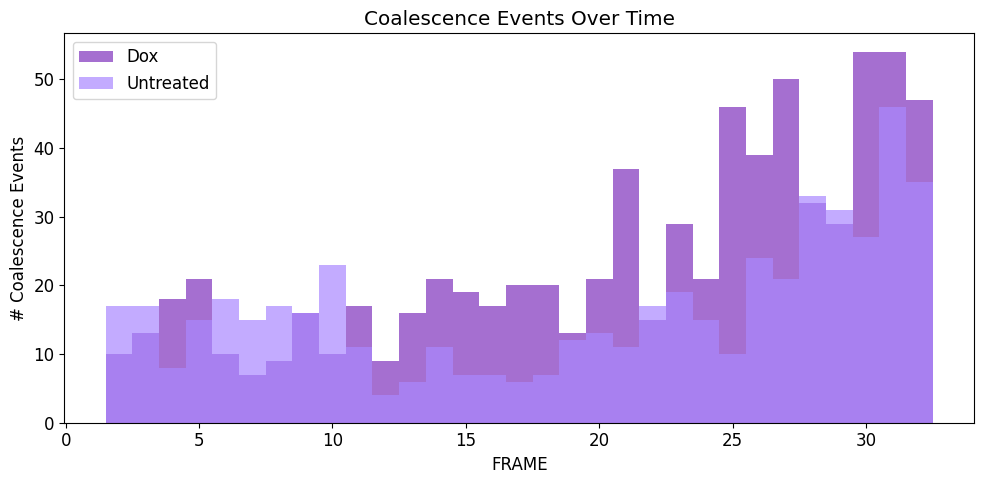

Saved coalescence histogram to /Volumes/mohrlab/mohrlabspace/Nora_Mohr/ANALYSIS/Condensates/250818-250903-250930-251001/coalescence_events_2-32_histogram.png


/Users/noralaineherzog/miniconda3/envs/tracking-env/lib/python3.10/site-packages/seaborn/categorical.py:3544: UserWarning: 19.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/noralaineherzog/miniconda3/envs/tracking-env/lib/python3.10/site-packages/seaborn/categorical.py:3544: UserWarning: 11.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/noralaineherzog/miniconda3/envs/tracking-env/lib/python3.10/site-packages/seaborn/categorical.py:3544: UserWarning: 17.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


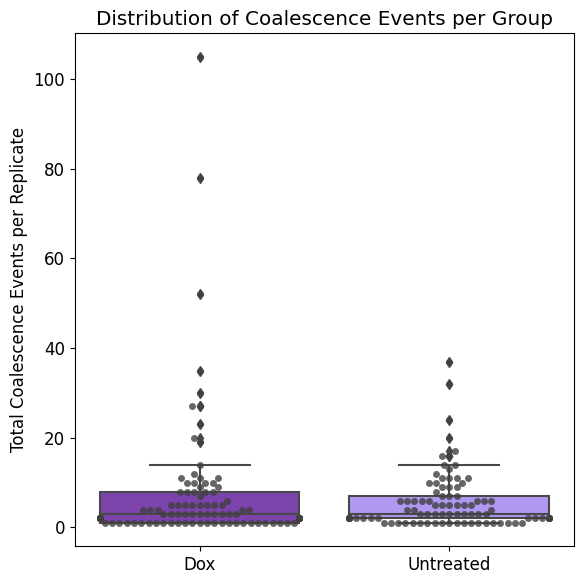

Saved coalescence boxplot to /Volumes/mohrlab/mohrlabspace/Nora_Mohr/ANALYSIS/Condensates/250818-250903-250930-251001/coalescence_events-total_2-32_boxplot.png


In [14]:
###THIS CODE IS ONLY IF LOOKING FOR COALESCENCE—WILL GRAPH THE OUTPUT ABOVE, OTHERWISE IT CAN BE SKIPPED

def compute_coalescence_events(dupes_df, group_label):
    """
    Takes a dupes_df and returns a DataFrame of coalescence events
    with columns: unique_name, FRAME, delta, group
    """
    if dupes_df.empty:
        return pd.DataFrame(columns=["unique_name", "FRAME", "rep_count", "rep_count_prev", "delta", "group"])
    
    # Count replicates per unique_name per FRAME
    counts = (
        dupes_df.groupby(["unique_name", "FRAME"])
        .size()
        .reset_index(name="rep_count")
    )

    # Sort by unique_name, FRAME
    counts = counts.sort_values(["unique_name", "FRAME"])

    # Compute replicate count difference vs previous frame
    counts["rep_count_prev"] = counts.groupby("unique_name")["rep_count"].shift(1)
    counts["delta"] = counts["rep_count_prev"] - counts["rep_count"]

    # A coalescence event is a drop by exactly 1
    coalescence_events = counts[counts["delta"] == 1].copy()
    coalescence_events["group"] = group_label

    return coalescence_events

def total_coalescence_per_replicate(dupes_df, group_label):
    """
    Returns a DataFrame with total coalescence events per replicate (original_filename)
    """
    if dupes_df.empty:
        return pd.DataFrame(columns=["original_filename", "total_events", "group"])
    
    # Count replicates per unique_name per FRAME
    counts = (
        dupes_df.groupby(["original_filename", "unique_name", "FRAME"])
        .size()
        .reset_index(name="rep_count")
    )
    
    # Sort by replicate and frame
    counts = counts.sort_values(["original_filename", "unique_name", "FRAME"])
    
    # Compute difference vs previous frame per unique_name per replicate
    counts["rep_count_prev"] = counts.groupby(["original_filename", "unique_name"])["rep_count"].shift(1)
    counts["delta"] = counts["rep_count_prev"] - counts["rep_count"]
    
    # Coalescence event = drop by exactly 1
    coalescence_events = counts[counts["delta"] == 1]
    
    # Total events per replicate
    total_events = (
        coalescence_events.groupby("original_filename")
        .size()
        .reset_index(name="total_events")
    )
    
    total_events["group"] = group_label
    return total_events

# Compute coalescence events for each group
events_dox = compute_coalescence_events(dupes_df_dox, "Dox")
events_un  = compute_coalescence_events(dupes_df_un, "Untreated")

# Combine for plotting
events_all = pd.concat([events_dox, events_un], ignore_index=True)

# Save combined df for later
events_out = os.path.join(output_folder, f"coalescense_events_framewise_{nuc_frame}-{lst}.csv")
events_all.to_csv(events_out, index=False)

# Count # events per FRAME per group
events_per_frame = events_all.groupby(["FRAME", "group"]).size().reset_index(name="num_events")

# --- Plot histogram over time ---
plt.figure(figsize=(10,5))

# Plot each group
for grp, df_grp in events_per_frame.groupby("group"):
    plt.bar(df_grp["FRAME"], df_grp["num_events"], 
            label=grp, 
            alpha=0.7, 
            width=1,
            color=color_map[grp])

plt.xlabel("FRAME")
plt.ylabel("# Coalescence Events")
plt.title("Coalescence Events Over Time")
plt.legend()
plt.tight_layout()

# Save figure
hist_file = os.path.join(output_folder, f"coalescence_events_{nuc_frame}-{lst}_histogram.png")
plt.savefig(hist_file)
plt.show()
print(f"Saved coalescence histogram to {hist_file}")

# Compute totals for both groups
totals_dox = total_coalescence_per_replicate(dupes_df_dox, "Dox")
totals_un  = total_coalescence_per_replicate(dupes_df_un, "Untreated")

# Combine for plotting
totals_all = pd.concat([totals_dox, totals_un], ignore_index=True)

# --- ADD SUMMARY COLUMNS ---
for grp, df_subset_range in zip(["Dox", "Untreated"], [df_subset_range_dox, df_subset_range_un]):
    # Total number of cells in the group
    total_cells = df_subset_range["original_filename"].nunique()
    
    # Total number of cells with coalescence events
    group_total_events = totals_all[totals_all["group"] == grp]
    cells_with_events = group_total_events["original_filename"].nunique()
    
    # Average number of coalescence events per total cells
    avg_events_per_cell = group_total_events["total_events"].sum() / total_cells if total_cells > 0 else 0
    
    # Proportion of cells with events
    prop_cells_with_events = cells_with_events / total_cells if total_cells > 0 else 0
    
    # Assign these values to a new row in totals_all
    totals_all.loc[totals_all["group"] == grp, "total_cells_in_group"] = total_cells
    totals_all.loc[totals_all["group"] == grp, "cells_with_events"] = cells_with_events
    totals_all.loc[totals_all["group"] == grp, "avg_events_per_total_cells"] = avg_events_per_cell
    totals_all.loc[totals_all["group"] == grp, "prop_cells_with_events"] = prop_cells_with_events

# Save combined df for later
totals_out = os.path.join(output_folder, f"coalescense_events_cellwise_{nuc_frame}-{lst}.csv")
totals_all.to_csv(totals_out, index=False)

# --- Boxplot ---
plt.figure(figsize=(6,6))
sns.boxplot(x="group", y="total_events", data=totals_all, palette=color_map)
sns.swarmplot(x="group", y="total_events", data=totals_all, color=".25", alpha=0.8)

plt.ylabel("Total Coalescence Events per Replicate")
plt.xlabel("")
plt.title("Distribution of Coalescence Events per Group")
plt.tight_layout()

# Save figure
boxplot_file = os.path.join(output_folder, f"coalescence_events-total_{nuc_frame}-{lst}_boxplot.png")
plt.savefig(boxplot_file)
plt.show()
print(f"Saved coalescence boxplot to {boxplot_file}")


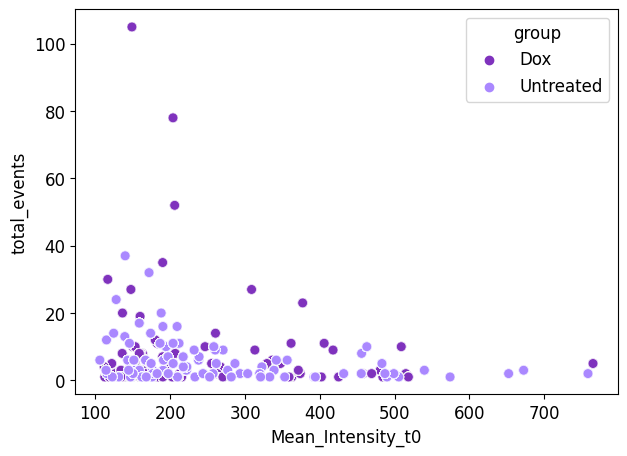

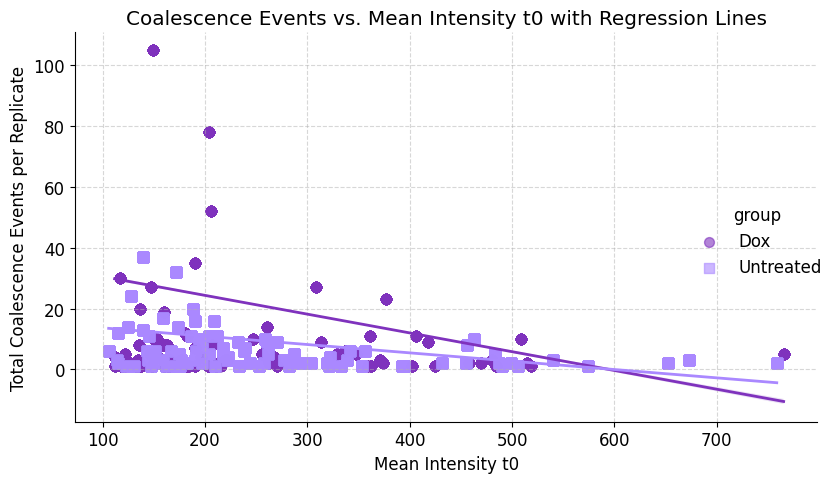

Saved scatter plot with regression lines to /Volumes/mohrlab/mohrlabspace/Nora_Mohr/ANALYSIS/Condensates/250818-250903-250930-251001/coalescence_vs_intensity_regression_2-32.png


In [15]:
# --- Scatter plot with regression lines: total coalescence events vs. mean intensity t0 ---

# Combine the Mean_Intensity_t0 data with totals_all
df_subset_range_dox["group"] = "Dox"
df_subset_range_un["group"]  = "Untreated"
intensity_all = pd.concat([df_subset_range_dox, df_subset_range_un], ignore_index=True)

# Merge on original_filename and group
scatter_df = pd.merge(
    totals_all, 
    intensity_all[['original_filename', 'Mean_Intensity_t0', 'group']],
    on=['original_filename', 'group'],
    how='inner'
)

# Scatter plot with regression lines per group
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=scatter_df,
    x="Mean_Intensity_t0",
    y="total_events",
    hue="group",
    palette=color_map,
    alpha=0.7,
    s=50
)

# Add linear regression lines per group
sns.lmplot(
    data=scatter_df,
    x="Mean_Intensity_t0",
    y="total_events",
    hue="group",
    palette=color_map,
    height=5,
    aspect=1.4,
    markers=["o","s"],
    scatter_kws={"alpha":0.6, "s":50},
    line_kws={"linewidth":2}
)

plt.xlabel("Mean Intensity t0")
plt.ylabel("Total Coalescence Events per Replicate")
plt.title("Coalescence Events vs. Mean Intensity t0 with Regression Lines")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

# Save figure
scatter_file = os.path.join(output_folder, f"coalescence_vs_intensity_regression_{nuc_frame}-{lst}.png")
plt.savefig(scatter_file)
plt.show()
print(f"Saved scatter plot with regression lines to {scatter_file}")



In [16]:
print(list(df_subset_range_dox.columns))
print(list(df_subset_range_un.columns))
print(df_subset_range_dox['FRAME'].dtype)
print(df_subset_range_dox['unique_name'].dtype)
print(df_subset_range_dox.head())

['original_filename', 'unique_name', 'Mean_Intensity_t0', 'ID', 'TRACK_ID', 'QUALITY', 'POSITION_X', 'POSITION_Y', 'POSITION_Z', 'POSITION_T', 'FRAME', 'RADIUS', 'VISIBILITY', 'MANUAL_SPOT_COLOR', 'MEAN_INTENSITY_CH1', 'MEDIAN_INTENSITY_CH1', 'MIN_INTENSITY_CH1', 'MAX_INTENSITY_CH1', 'TOTAL_INTENSITY_CH1', 'STD_INTENSITY_CH1', 'EXTRACK_P_STUCK', 'EXTRACK_P_DIFFUSIVE', 'CONTRAST_CH1', 'SNR_CH1', 'ELLIPSE_X0', 'ELLIPSE_Y0', 'ELLIPSE_MAJOR', 'ELLIPSE_MINOR', 'ELLIPSE_THETA', 'ELLIPSE_ASPECTRATIO', 'AREA', 'PERIMETER', 'CIRCULARITY', 'SOLIDITY', 'SHAPE_INDEX', 'COUNT', 'Group', 'group']
['original_filename', 'unique_name', 'Mean_Intensity_t0', 'ID', 'TRACK_ID', 'QUALITY', 'POSITION_X', 'POSITION_Y', 'POSITION_Z', 'POSITION_T', 'FRAME', 'RADIUS', 'VISIBILITY', 'MANUAL_SPOT_COLOR', 'MEAN_INTENSITY_CH1', 'MEDIAN_INTENSITY_CH1', 'MIN_INTENSITY_CH1', 'MAX_INTENSITY_CH1', 'TOTAL_INTENSITY_CH1', 'STD_INTENSITY_CH1', 'EXTRACK_P_STUCK', 'EXTRACK_P_DIFFUSIVE', 'CONTRAST_CH1', 'SNR_CH1', 'ELLIPSE_X0'

In [17]:
def normalize_group(df_subset, group_name, nuc_frame, lst, output_folder):
    df_subset = df_subset.copy()
    df_subset['FRAME'] = df_subset['FRAME'].astype(int)

    # --- STEP 1: Normalize intensity columns to Mean_Intensity_t0 ---
    intensity_cols = ["MEAN_INTENSITY_CH1", "MEDIAN_INTENSITY_CH1", "TOTAL_INTENSITY_CH1"]
    for col in intensity_cols:
        df_subset[f"{col}_t0NORM"] = df_subset[col] / df_subset["Mean_Intensity_t0"]

    # --- STEP 2: Normalize RADIUS, AREA, PERIMETER to their value at nuc_frame ---
    norm_cols_direct = ["RADIUS", "AREA", "PERIMETER"]

    # Filter only names present at nuc_frame
    valid_names = df_subset[df_subset["FRAME"] == nuc_frame]["unique_name"].unique()
    filtered_df = df_subset[df_subset["unique_name"].isin(valid_names)].copy()

    if filtered_df.empty:
        print(f"No data for nuc_frame {nuc_frame} in group {group_name}")
        return pd.DataFrame()  # skip normalization

    # Create reference for each unique_name at nuc_frame
    ref_direct = filtered_df[filtered_df["FRAME"] == nuc_frame].set_index("unique_name")[norm_cols_direct]

    # --- STEP X: Check for duplicates at nuc_frame ---
    dupes = ref_direct.index[ref_direct.index.duplicated()]

    if len(dupes) > 0:
        print(f"Found {len(dupes)} duplicate unique_names at nuc_frame {nuc_frame}")

        # Collect all rows for those dupes between nuc_frame and lst
        dupes_df = (
            filtered_df[
                (filtered_df["unique_name"].isin(dupes)) &
                (filtered_df["FRAME"].between(nuc_frame, lst))
            ]
            .copy()
        )

        # Save to CSV
        dupes_file = f"coalescing-spots_{group_name}_{nuc_frame}-{lst}_dupes.csv"
        dupes_df.to_csv(os.path.join(output_folder, dupes_file), index=False)
        print(f"Saved dupes to {dupes_file}")
    else:
        print("No duplicate unique_names found at nuc_frame")

    # Aggregate reference values at nuc_frame in case of duplicates
    ref_direct = (filtered_df[filtered_df["FRAME"] == nuc_frame].groupby("unique_name")[norm_cols_direct].mean())   # or .median() if that's more biologically correct

    def normalize_direct(group):
        group = group.copy()
        if nuc_frame in group["FRAME"].values:
            ref = ref_direct.loc[group["unique_name"].iloc[0]]
            for col in norm_cols_direct:
                ref_val = ref[col]
                group[f"{col}_NORM"] = group[col] / ref_val
        else:
            print(f"Skipping direct norm for {group['unique_name'].iloc[0]}")
        return group

    filtered_df = filtered_df.groupby("unique_name", group_keys=False).apply(normalize_direct)

    # --- STEP 3: Normalize *_t0NORM columns to their value at nuc_frame ---
    norm_cols_t0norm = [f"{col}_t0NORM" for col in intensity_cols]
    #ref_t0norm = filtered_df[filtered_df["FRAME"] == nuc_frame].set_index("unique_name")[norm_cols_t0norm]

    # Again aggregate in case of duplicates
    ref_t0norm = (filtered_df[filtered_df["FRAME"] == nuc_frame].groupby("unique_name")[norm_cols_t0norm].mean())

    def normalize_t0(group):
        group = group.copy()
        if nuc_frame in group["FRAME"].values:
            ref = ref_t0norm.loc[group["unique_name"].iloc[0]]
            for col in norm_cols_t0norm:
                group[col.replace("_t0NORM", "_NORM")] = group[col] / ref[col]
        else:
            print(f"Skipping t0norm for {group['unique_name'].iloc[0]}")
        return group

    filtered_df = filtered_df.groupby("unique_name", group_keys=False).apply(normalize_t0).reset_index(drop=True)

    # --- STEP 4: Filter range and compute COUNT ---
    filtered_df = filtered_df[(filtered_df["FRAME"] >= (nuc_frame - 1)) & 
                              (filtered_df["FRAME"] <= lst)].copy()
    
    filtered_df["COUNT"] = filtered_df["FRAME"] - nuc_frame + 1

    # --- STEP 5: Save to CSV ---
    filename = f"normalized_spots_{group_name}_{nuc_frame}-{lst}.csv"
    save_path = os.path.join(output_folder, filename)
    filtered_df.to_csv(save_path, index=False)

    print(f"Saved normalized dataframe for {group_name} to: {save_path}")
    return filtered_df

# Apply to both groups
df_norm_dox = normalize_group(df_subset_range_dox, "Dox", nuc_frame, lst, concat_folder)
df_norm_un = normalize_group(df_subset_range_un, "Untreated", nuc_frame, lst, concat_folder)


Found 87 duplicate unique_names at nuc_frame 2
Saved dupes to coalescing-spots_Dox_2-32_dupes.csv
Saved normalized dataframe for Dox to: /Volumes/mohrlab/mohrlabspace/Nora_Mohr/ANALYSIS/Condensates/250818-250903-250930-251001/normalized_spots_Dox_2-32.csv
Found 99 duplicate unique_names at nuc_frame 2
Saved dupes to coalescing-spots_Untreated_2-32_dupes.csv
Saved normalized dataframe for Untreated to: /Volumes/mohrlab/mohrlabspace/Nora_Mohr/ANALYSIS/Condensates/250818-250903-250930-251001/normalized_spots_Untreated_2-32.csv


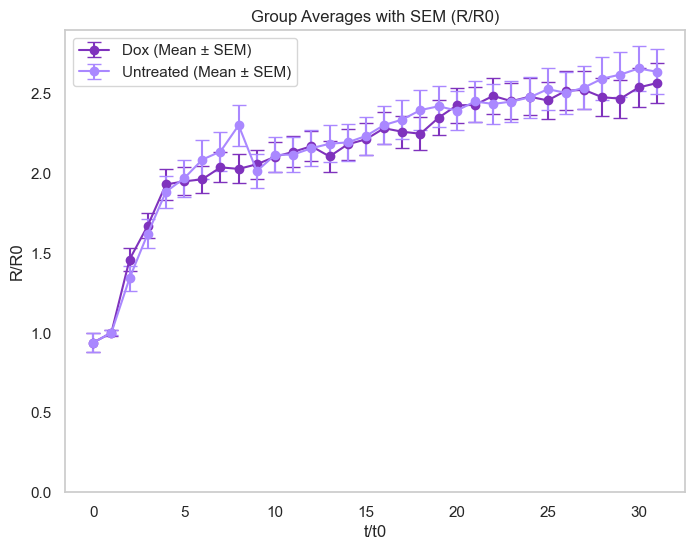

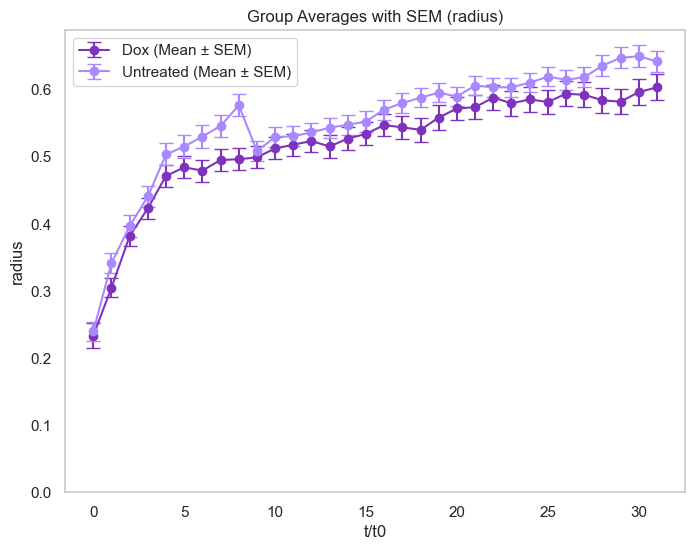

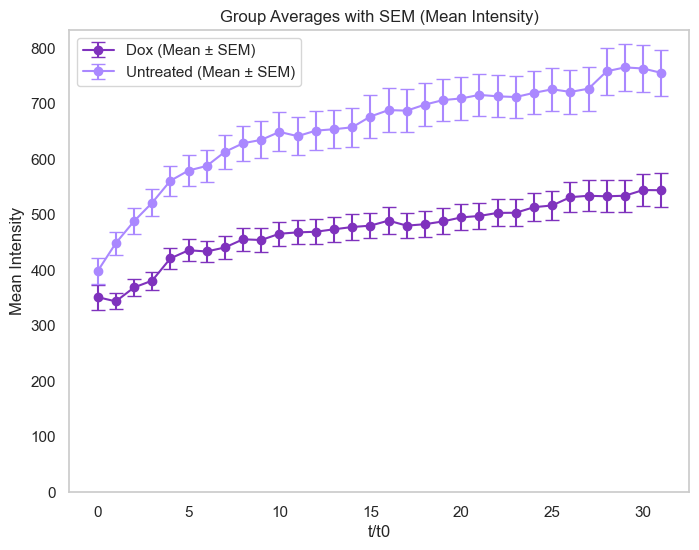

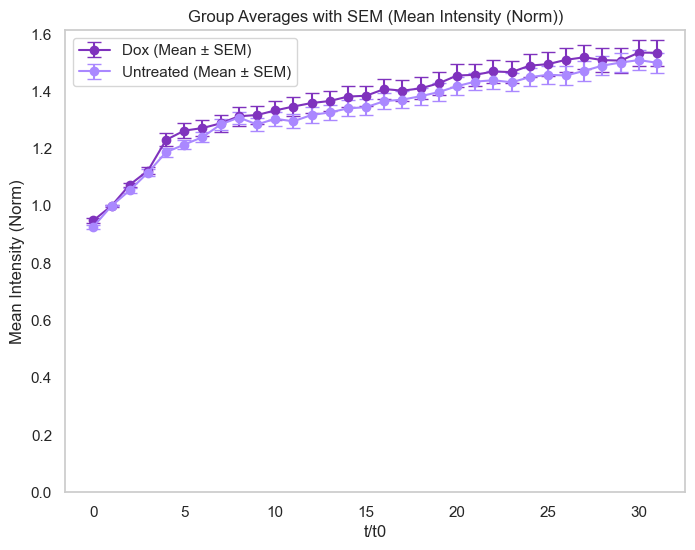

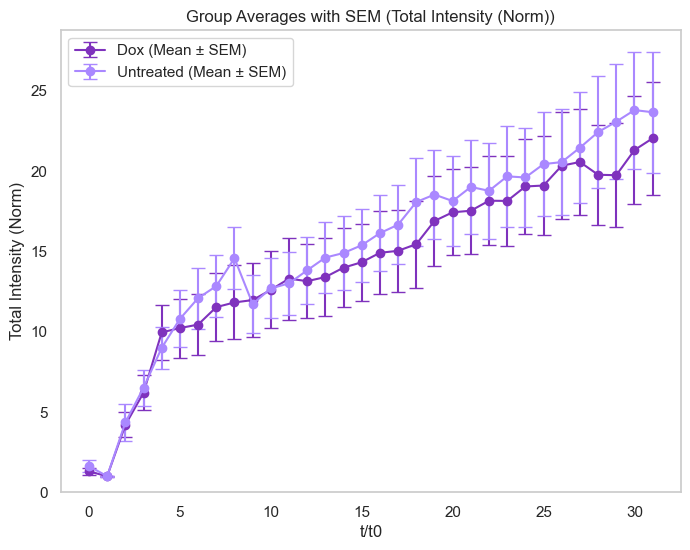

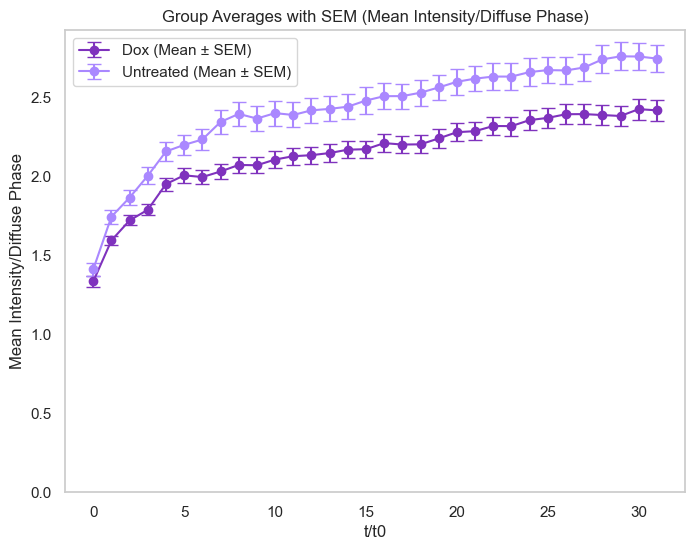

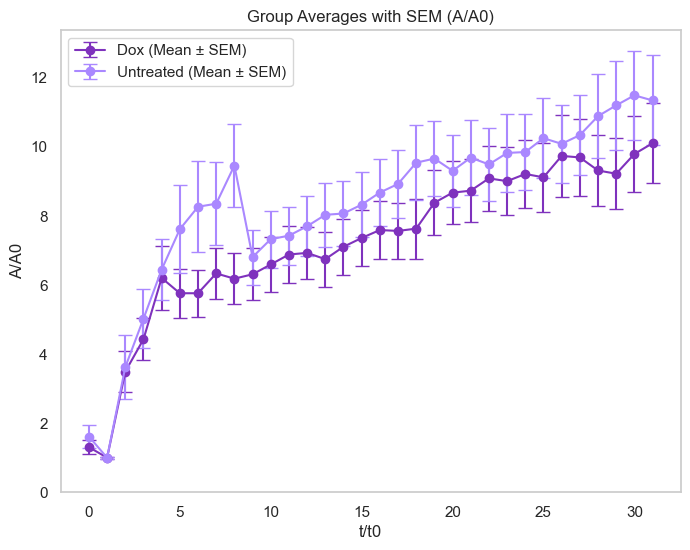

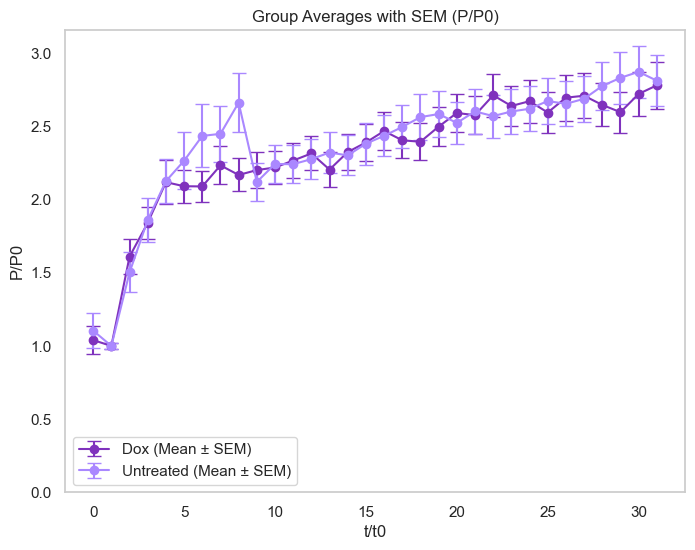

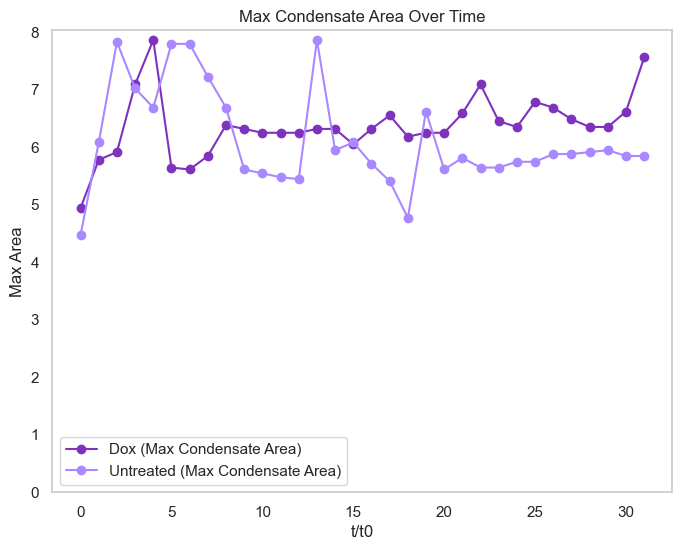

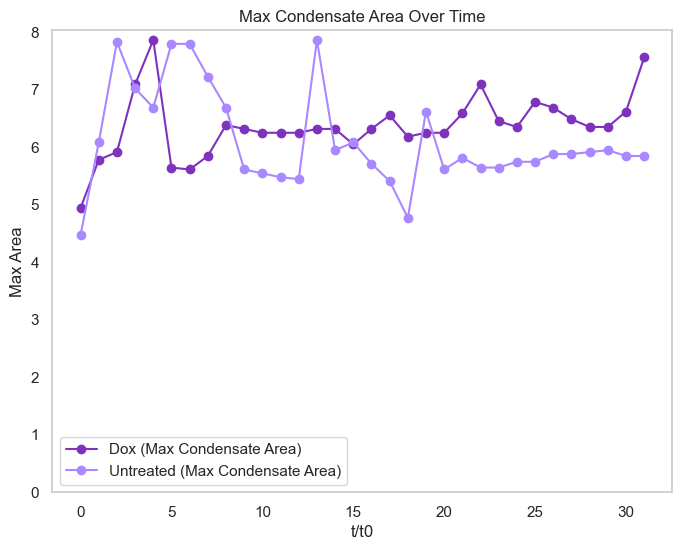

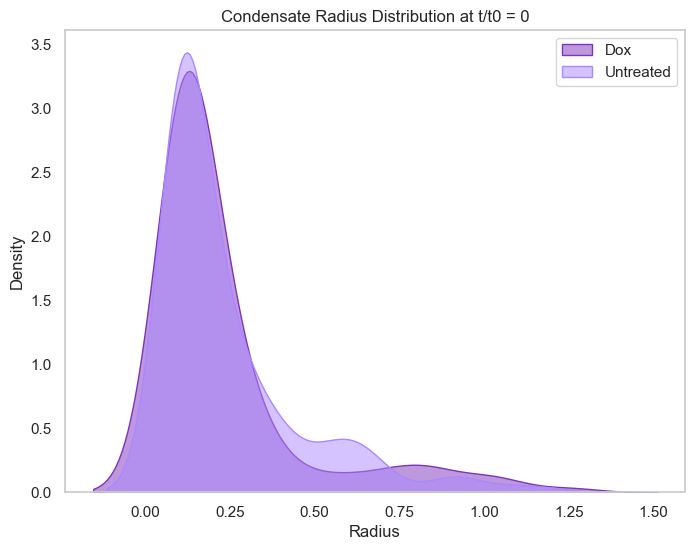

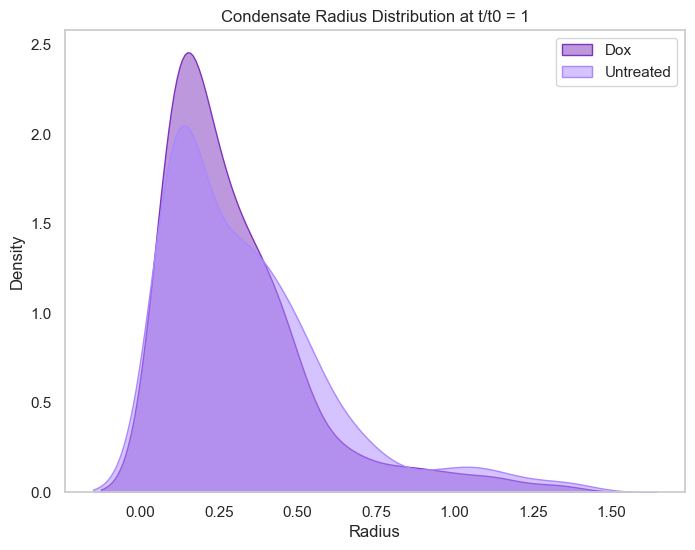

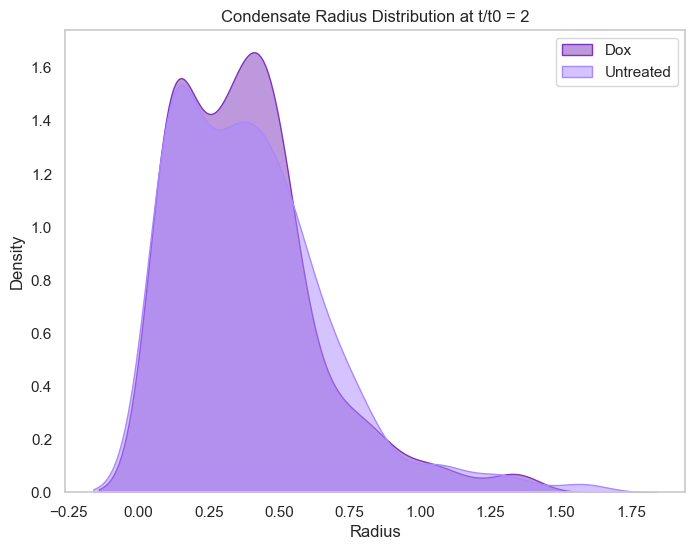

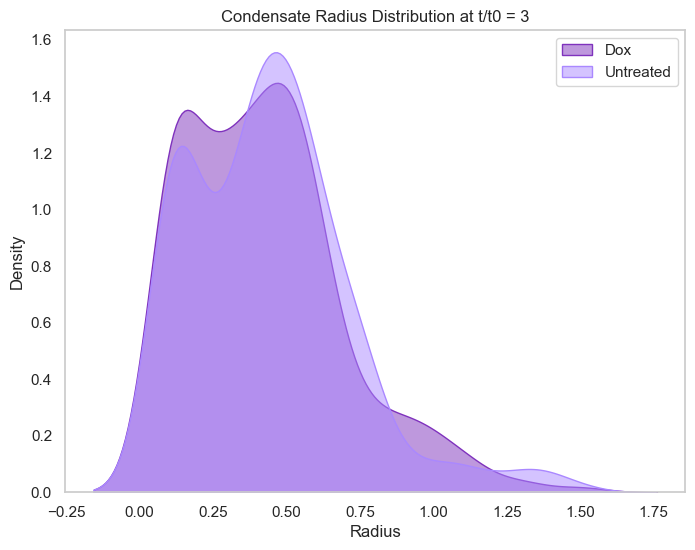

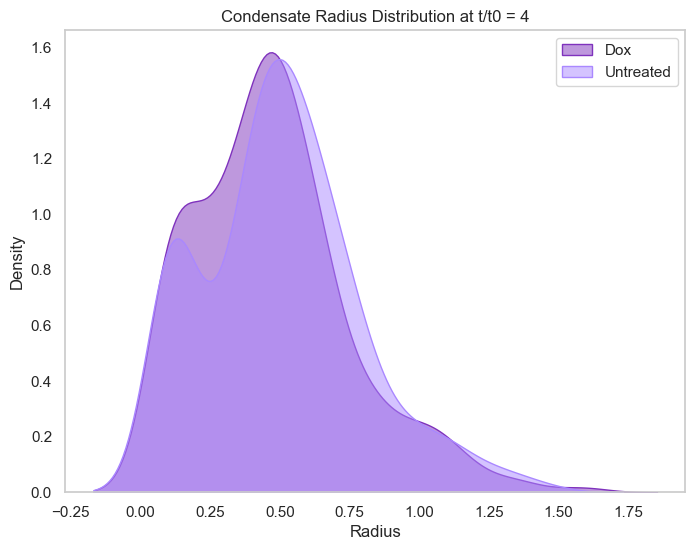

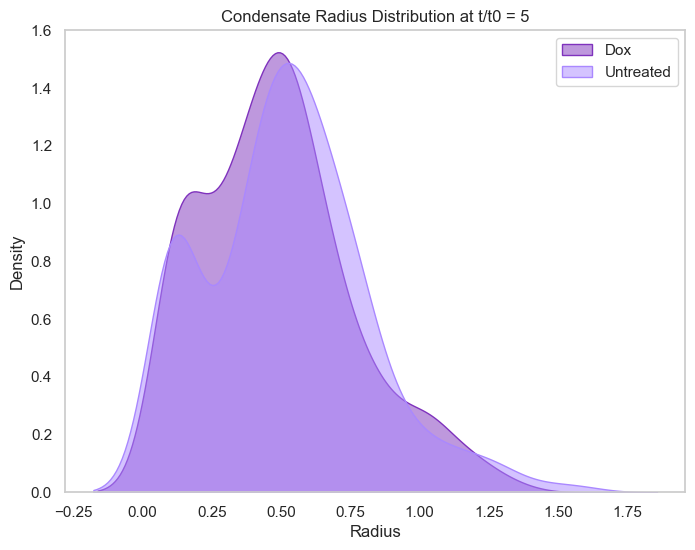

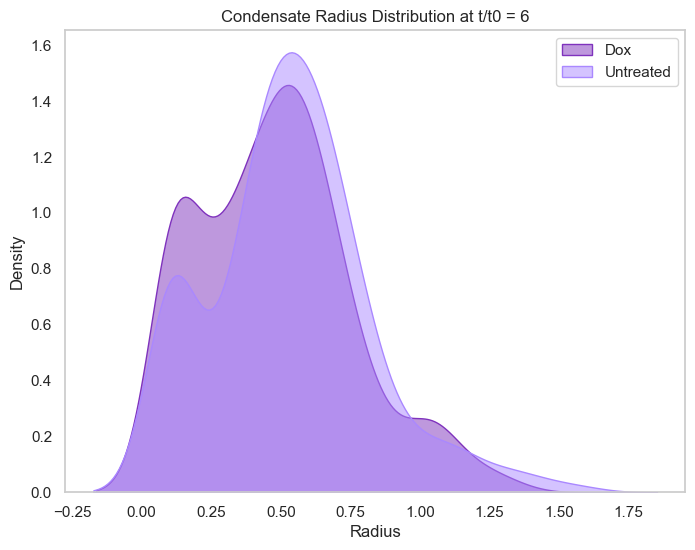

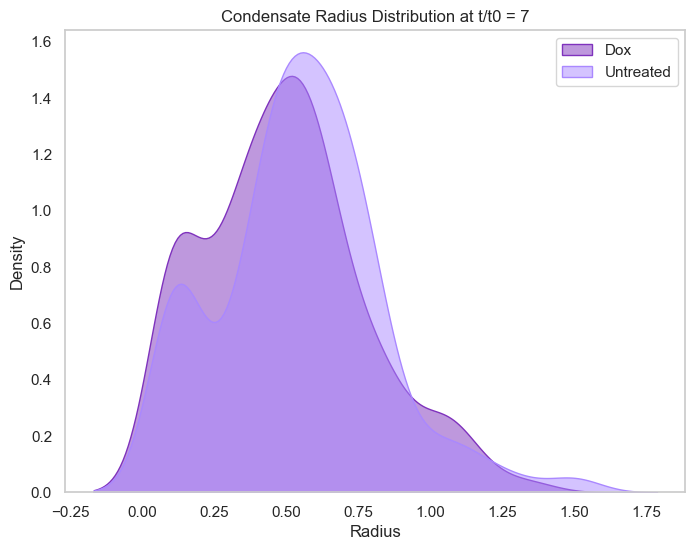

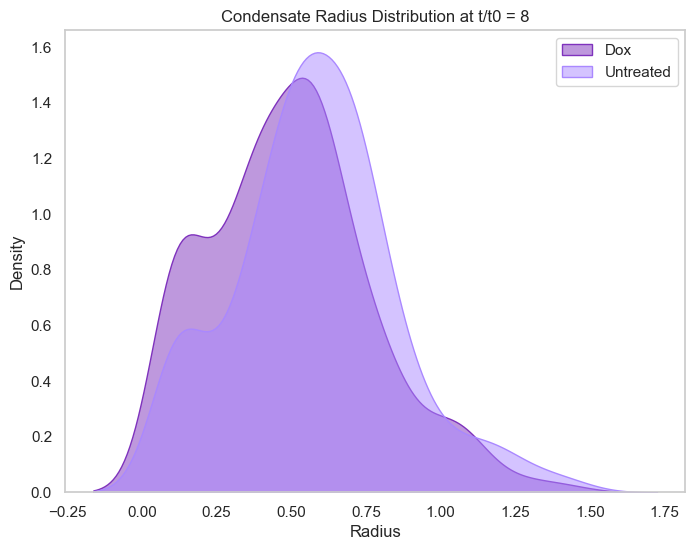

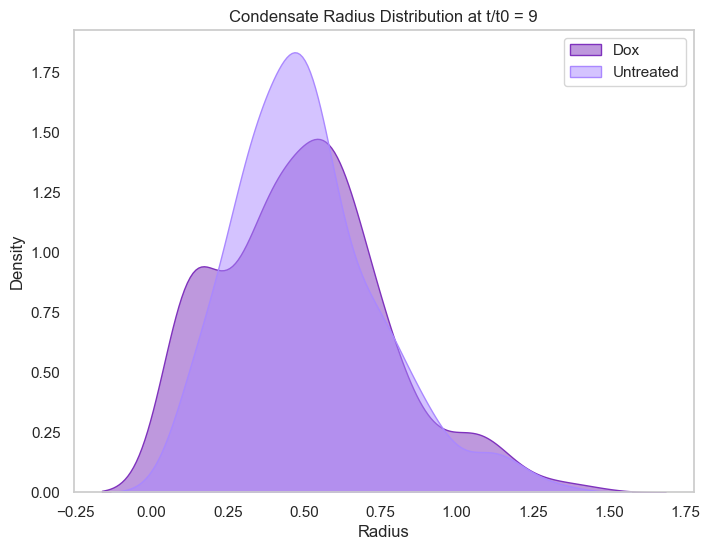

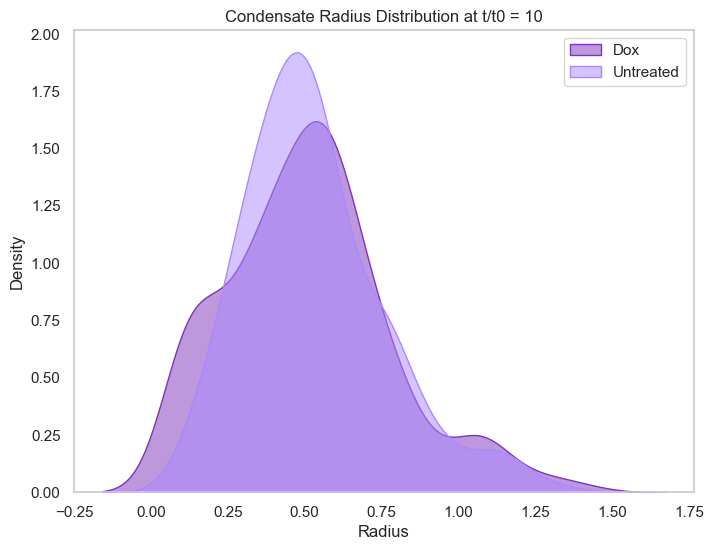

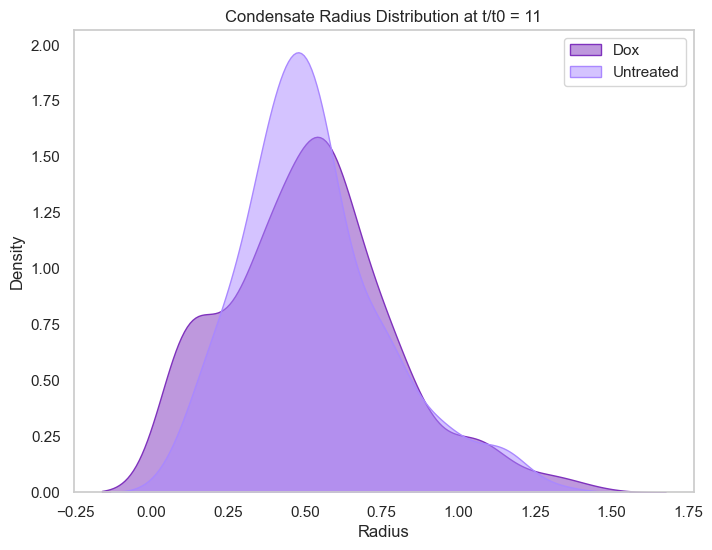

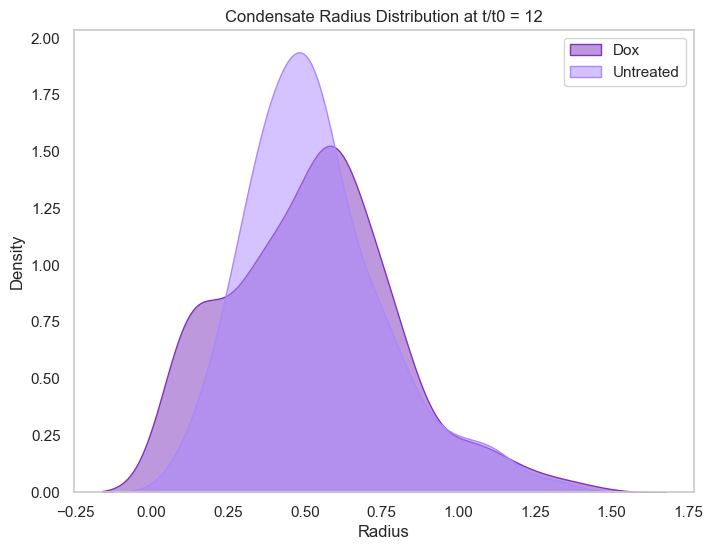

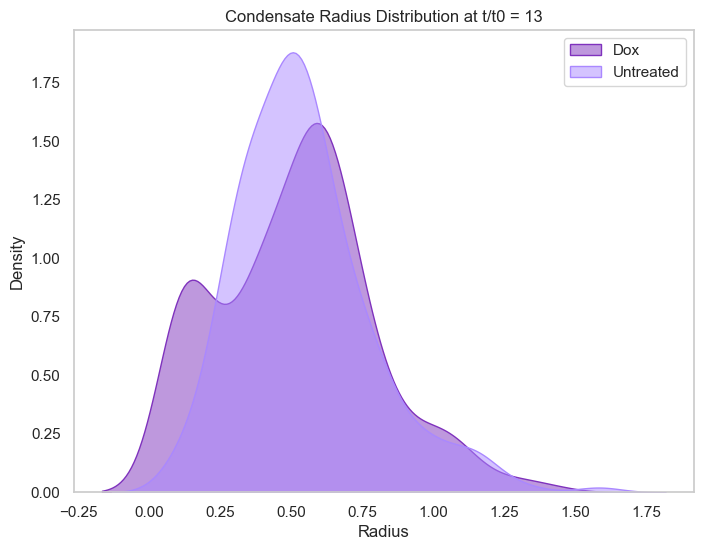

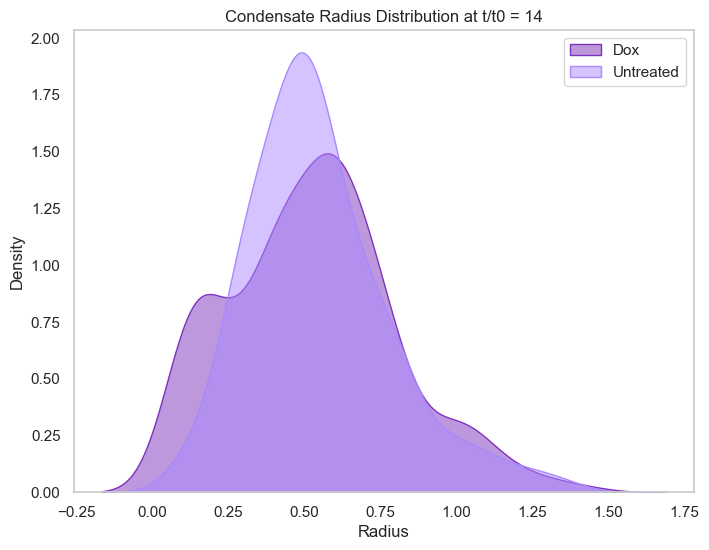

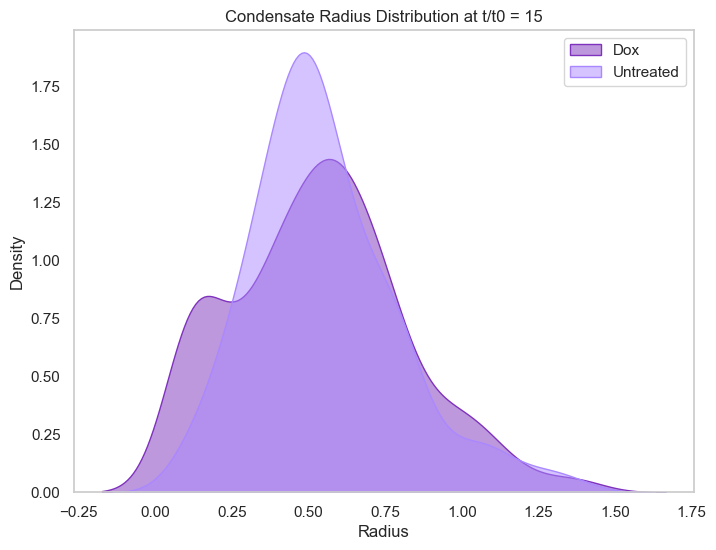

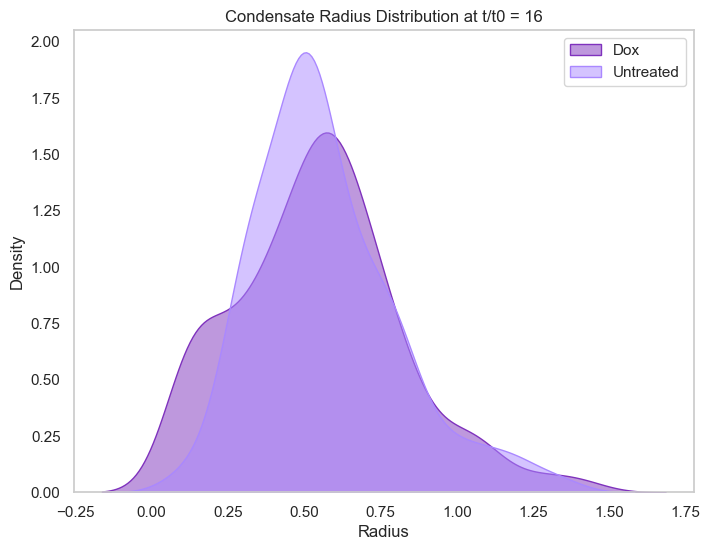

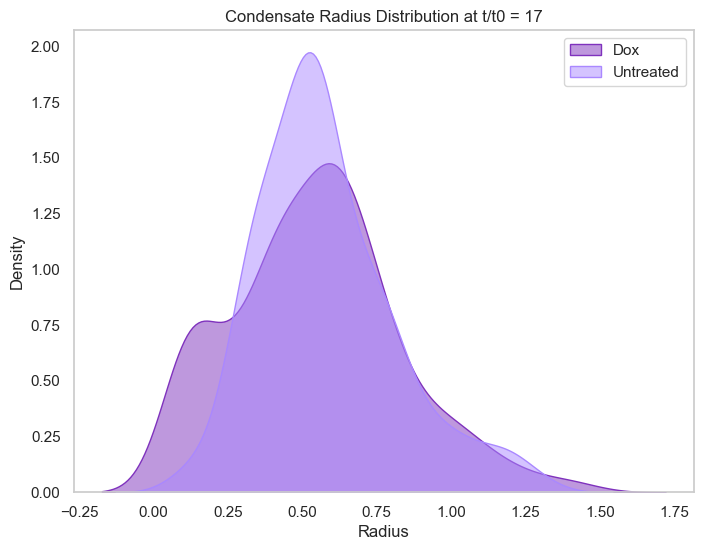

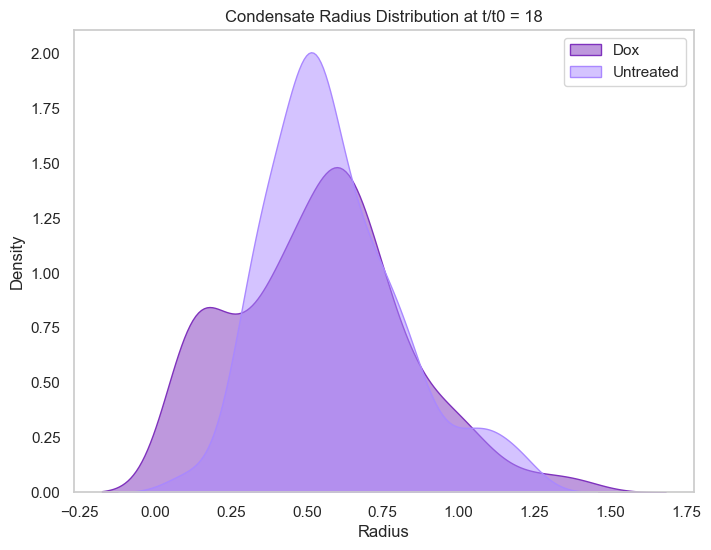

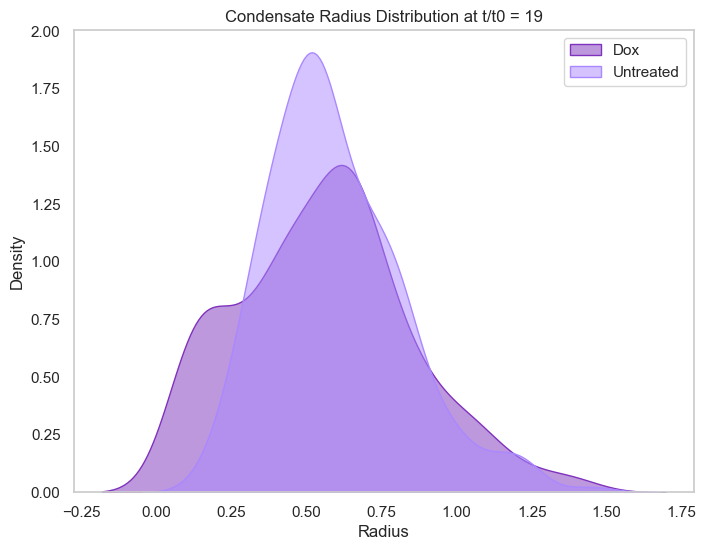

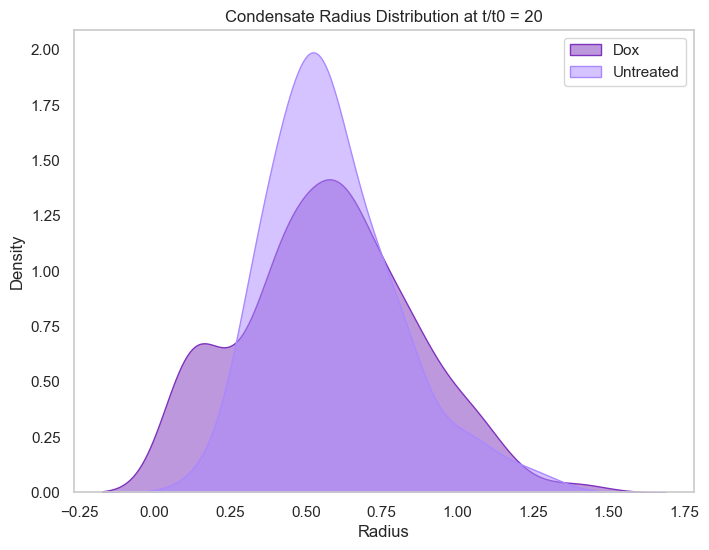

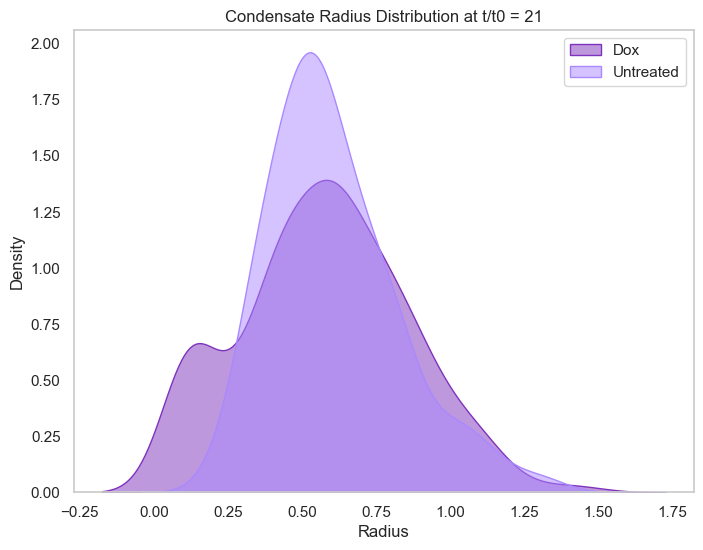

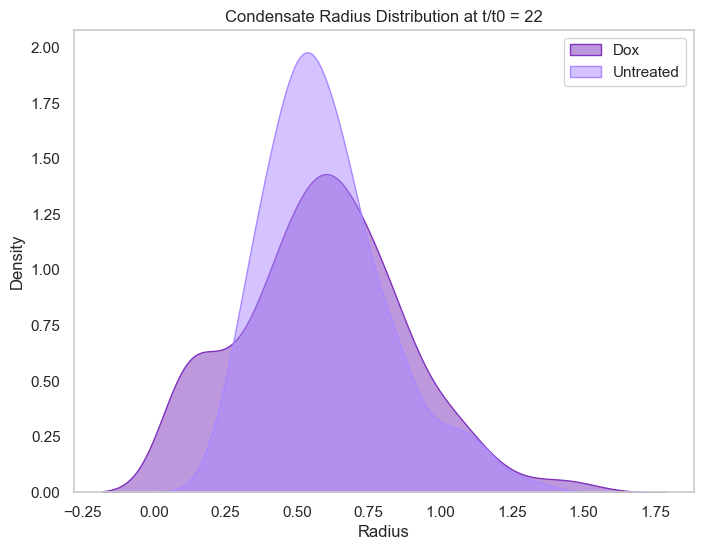

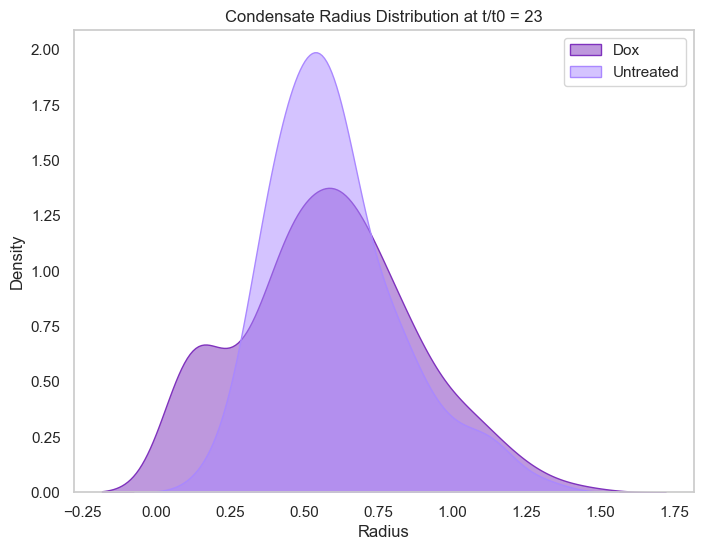

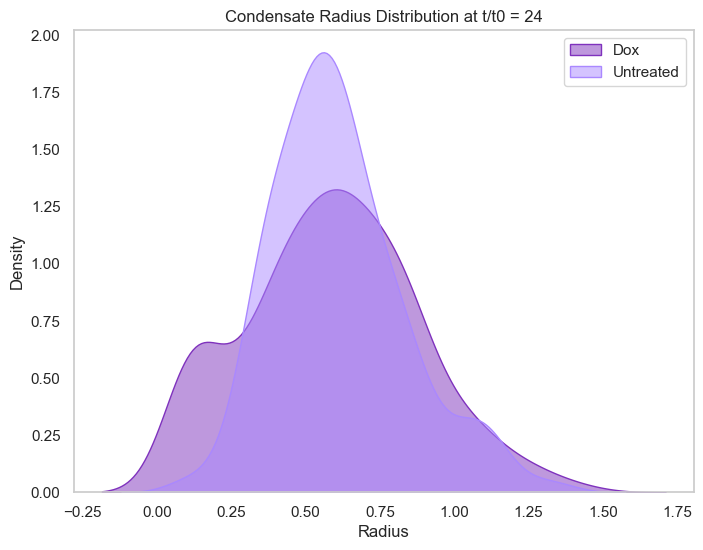

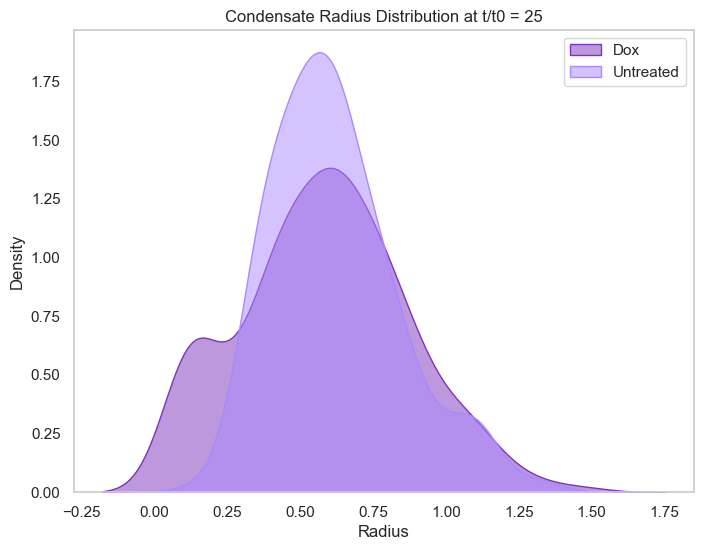

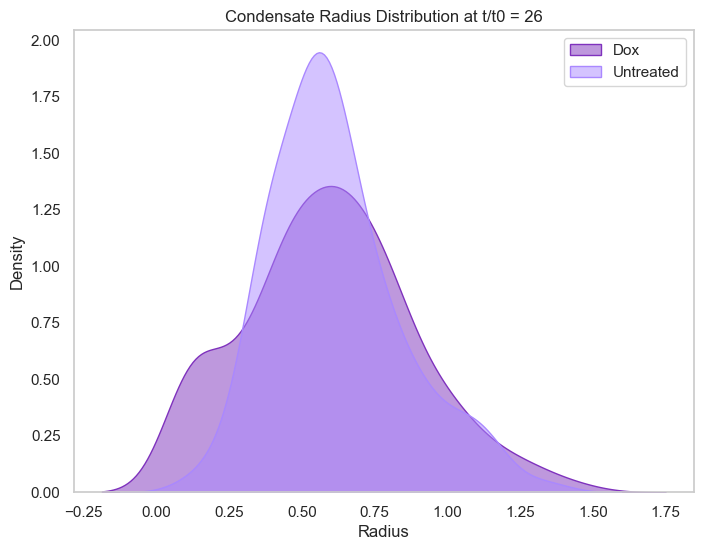

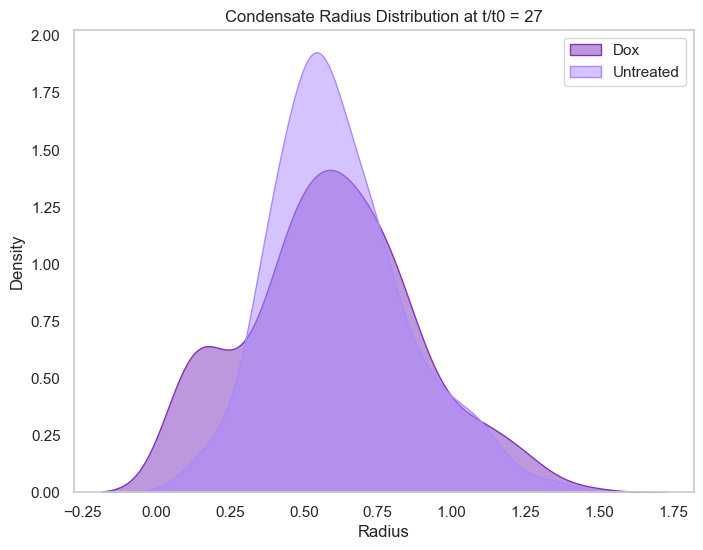

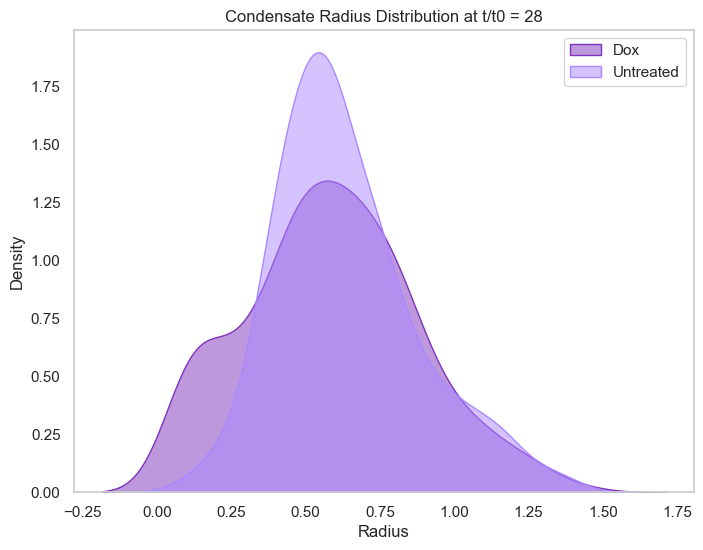

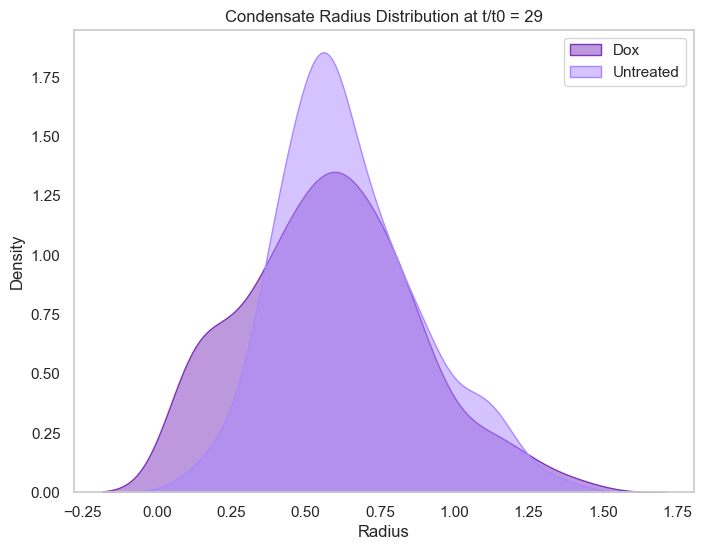

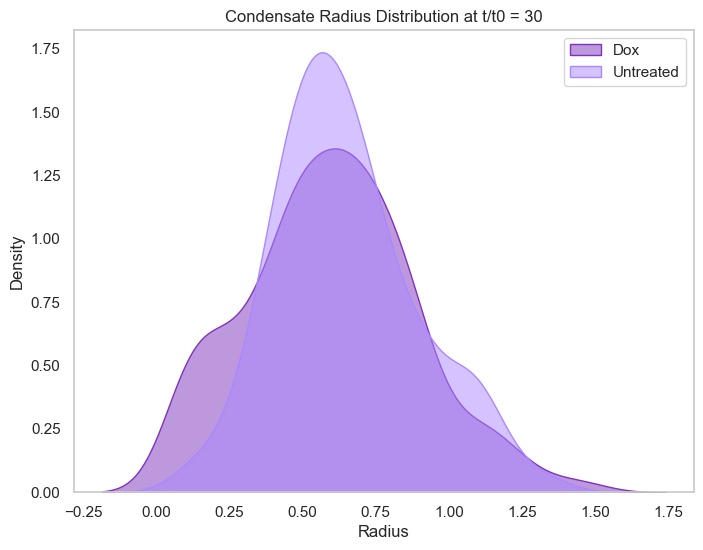

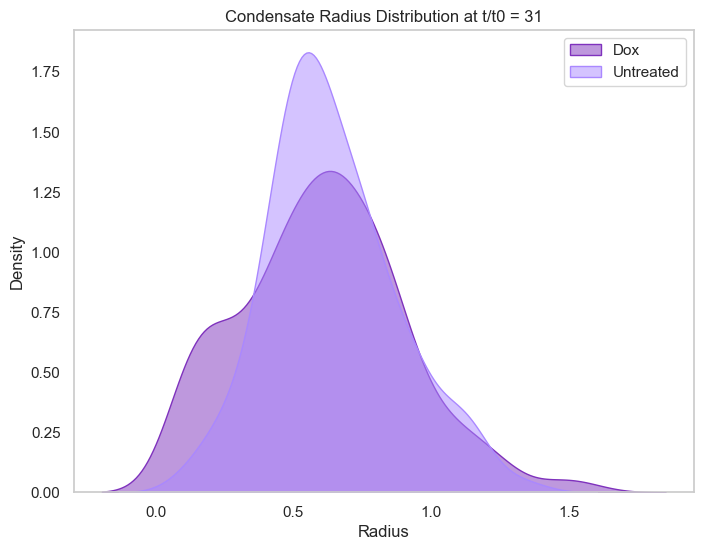

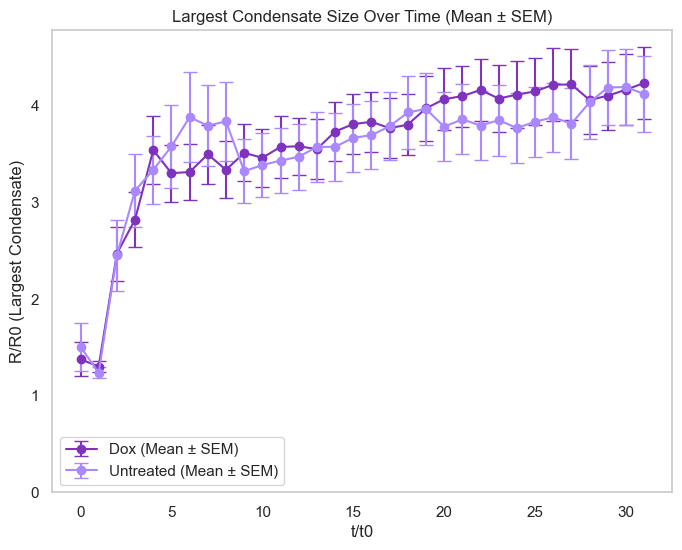

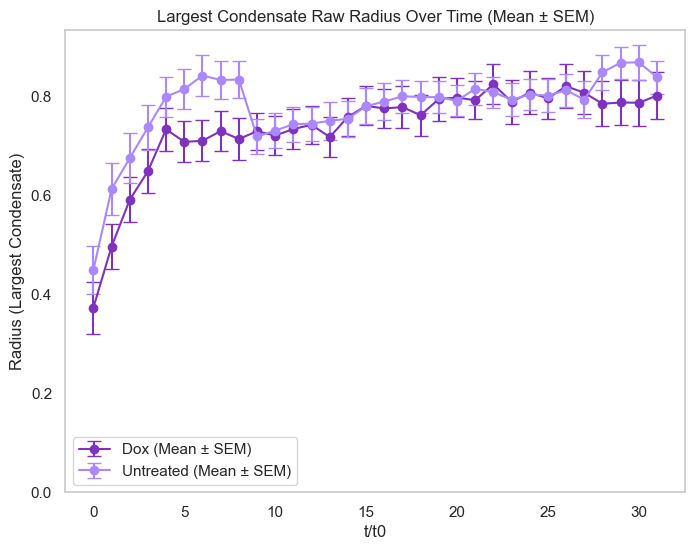

In [ ]:
# Define colors
dox_dark = "#7f32bd"
untreated_dark = "#aa88ff"

# Define variables and their shorthand names
variables = {
    "RADIUS_NORM": "radius",
    "RADIUS": "radius-NO-NORM",
    "MEAN_INTENSITY_CH1": "mean-intensity-NO-NORM",
    "MEAN_INTENSITY_CH1_NORM": "mean-intensity",
    "TOTAL_INTENSITY_CH1_NORM": "total-intensity",
    "MEAN_INTENSITY_CH1_t0NORM": "mean-intensity-t0",
    "AREA_NORM": "area",
    "PERIMETER_NORM": "perimeter",
}
y_labels = {
    "RADIUS_NORM": "R/R0",
    "RADIUS": "radius",
    "MEAN_INTENSITY_CH1": "Mean Intensity",
    "MEAN_INTENSITY_CH1_NORM": "Mean Intensity (Norm)",
    "TOTAL_INTENSITY_CH1_NORM": "Total Intensity (Norm)",
    "MEAN_INTENSITY_CH1_t0NORM": "Mean Intensity/Diffuse Phase",
    "AREA_NORM": "A/A0",
    "PERIMETER_NORM": "P/P0",
}

# Loop over each variable to create the group average + SEM plots
for var, shorthand in variables.items():
    plt.figure(figsize=(8, 6))

    # Group means
    dox_avg = df_norm_dox.groupby("COUNT")[var].mean()
    untreated_avg = df_norm_un.groupby("COUNT")[var].mean()

    # Group SEMs
    dox_sem = df_norm_dox.groupby("COUNT")[var].sem()
    untreated_sem = df_norm_un.groupby("COUNT")[var].sem()

    # Plot with error bars
    plt.errorbar(dox_avg.index, dox_avg.values, yerr=dox_sem.values, fmt="o-", color=dox_dark,
                 capsize=5, label="Dox (Mean ± SEM)")
    plt.errorbar(untreated_avg.index, untreated_avg.values, yerr=untreated_sem.values, fmt="o-",
                 color=untreated_dark, capsize=5, label="Untreated (Mean ± SEM)")
    
    '''# Filter p-values for this variable
    sig_data = df_stats[(df_stats["variable"] == var) & (df_stats["p_value"] < 0.05)]

    # Overlay p-values where significant
    for _, row in sig_data.iterrows():
        x = row["count"]
        y_max = max(dox_avg.get(x, 0), untreated_avg.get(x, 0))  # get y-position to place marker just above highest group mean
        y_err = max(dox_sem.get(x, 0), untreated_sem.get(x, 0))
        y_offset = y_max + y_err + 0.05  # add a bit of vertical space
        
        # Add star and p-value text
        plt.text(x, y_offset, "*", ha="center", va="bottom", fontsize=14, color="black")'''


    # Labels and title
    plt.xlabel("t/t0")
    plt.ylabel(y_labels[var])
    plt.title(f"Group Averages with SEM ({y_labels[var]})")
    plt.legend()
    plt.grid(False)
    plt.ylim(bottom=0)

    # Save the plot
    plt.savefig(f"{output_folder}/{shorthand}-avg_norm_spots_{nuc_frame}-{lst}.png", bbox_inches="tight", dpi=300)
    plt.show()

# Plot the largest condensate area at each timepoint for each group
plt.figure(figsize=(8, 6))

# Get the largest area at each timepoint
dox_max_area = df_norm_dox.groupby("COUNT")["AREA"].max()
untreated_max_area = df_norm_un.groupby("COUNT")["AREA"].max()

# Plot the max values
plt.plot(dox_max_area.index, dox_max_area.values, "o-", color=dox_dark, label="Dox (Max Condensate Area)")
plt.plot(untreated_max_area.index, untreated_max_area.values, "o-", color=untreated_dark, label="Untreated (Max Condensate Area)")

# Labels and title
plt.xlabel("t/t0")
plt.ylabel("Max Area")
plt.title("Max Condensate Area Over Time")
plt.legend()
plt.grid(False)
plt.ylim(bottom=0)

# Save the plot
plt.savefig(f"{output_folder}/area-largest_{nuc_frame}-{lst}.png", bbox_inches="tight", dpi=300)
plt.show()


#To graph probability distribution of size
# Set up plot style
sns.set(style="whitegrid")

# Combine both groups and label them for plotting
df_dox_r = df_norm_dox.copy()
df_dox_r["Group"] = "Dox"

df_un_r = df_norm_un.copy()
df_un_r["Group"] = "Untreated"

df_combined = pd.concat([df_dox_r, df_un_r], ignore_index=True)

# Loop over each timepoint
timepoints = sorted(df_combined["COUNT"].unique())

for tp in timepoints:
    plt.figure(figsize=(8, 6))
    
    # Filter for the current timepoint
    df_tp = df_combined[df_combined["COUNT"] == tp]

    # Plot KDE for RADIUS per group
    sns.kdeplot(data=df_tp[df_tp["Group"] == "Dox"], x="RADIUS", fill=True, label="Dox", color=dox_dark, alpha=0.5)
    sns.kdeplot(data=df_tp[df_tp["Group"] == "Untreated"], x="RADIUS", fill=True, label="Untreated", color=untreated_dark, alpha=0.5)

    plt.xlabel("Radius")
    plt.ylabel("Density")
    plt.title(f"Condensate Radius Distribution at t/t0 = {tp}")
    plt.legend()
    plt.grid(False)
    plt.ylim(bottom=0)

    # Save the figure
    plt.savefig(f"{output_folder}/radius_distribution_t{tp}_{nuc_frame}-{lst}.png", bbox_inches="tight", dpi=300)
    
    plt.show()


# --- Plot largest condensate normalized radius (mean ± SEM) ---
plt.figure(figsize=(8, 6))

# compute largest condensate per cell per timepoint
df_norm_dox_largest = (
    df_norm_dox.sort_values(by=["COUNT", "original_filename", "RADIUS_NORM"], ascending=False)
               .groupby(["COUNT", "original_filename"])
               .first()
               .reset_index()
)

df_norm_un_largest = (
    df_norm_un.sort_values(by=["COUNT", "original_filename", "RADIUS_NORM"], ascending=False)
              .groupby(["COUNT", "original_filename"])
              .first()
              .reset_index()
)

# compute group averages and SEM
dox_largest_avg = df_norm_dox_largest.groupby("COUNT")["RADIUS_NORM"].mean()
dox_largest_sem = df_norm_dox_largest.groupby("COUNT")["RADIUS_NORM"].sem()

unt_largest_avg = df_norm_un_largest.groupby("COUNT")["RADIUS_NORM"].mean()
unt_largest_sem = df_norm_un_largest.groupby("COUNT")["RADIUS_NORM"].sem()

# plot mean ± SEM
plt.errorbar(dox_largest_avg.index, dox_largest_avg.values, yerr=dox_largest_sem.values,
             fmt="o-", color=dox_dark, capsize=5, label="Dox (Mean ± SEM)")

plt.errorbar(unt_largest_avg.index, unt_largest_avg.values, yerr=unt_largest_sem.values,
             fmt="o-", color=untreated_dark, capsize=5, label="Untreated (Mean ± SEM)")

# labels and formatting
plt.xlabel("t/t0")
plt.ylabel("R/R0 (Largest Condensate)")
plt.title("Largest Condensate Size Over Time (Mean ± SEM)")
plt.legend()
plt.grid(False)
plt.ylim(bottom=0)

# save
plt.savefig(f"{output_folder}/largest_radius_norm_avg_{nuc_frame}-{lst}.png",
            bbox_inches="tight", dpi=300)
plt.show()


# --- Plot largest condensate raw radius (mean ± SEM) ---
plt.figure(figsize=(8, 6))

# compute largest condensate per cell per timepoint
df_norm_dox_largest_raw = (
    df_norm_dox.sort_values(by=["COUNT", "original_filename", "RADIUS"], ascending=False)
               .groupby(["COUNT", "original_filename"])
               .first()
               .reset_index()
)

df_norm_un_largest_raw = (
    df_norm_un.sort_values(by=["COUNT", "original_filename", "RADIUS"], ascending=False)
              .groupby(["COUNT", "original_filename"])
              .first()
              .reset_index()
)

# compute group averages and SEM
dox_largest_raw_avg = df_norm_dox_largest_raw.groupby("COUNT")["RADIUS"].mean()
dox_largest_raw_sem = df_norm_dox_largest_raw.groupby("COUNT")["RADIUS"].sem()

unt_largest_raw_avg = df_norm_un_largest_raw.groupby("COUNT")["RADIUS"].mean()
unt_largest_raw_sem = df_norm_un_largest_raw.groupby("COUNT")["RADIUS"].sem()

# plot mean ± SEM
plt.errorbar(dox_largest_raw_avg.index, dox_largest_raw_avg.values, yerr=dox_largest_raw_sem.values,
             fmt="o-", color=dox_dark, capsize=5, label="Dox (Mean ± SEM)")

plt.errorbar(unt_largest_raw_avg.index, unt_largest_raw_avg.values, yerr=unt_largest_raw_sem.values,
             fmt="o-", color=untreated_dark, capsize=5, label="Untreated (Mean ± SEM)")

# labels and formatting
plt.xlabel("t/t0")
plt.ylabel("Radius (Largest Condensate)")
plt.title("Largest Condensate Raw Radius Over Time (Mean ± SEM)")
plt.legend()
plt.grid(False)
plt.ylim(bottom=0)

# save
plt.savefig(f"{output_folder}/largest_radius_raw_avg_{nuc_frame}-{lst}.png",
            bbox_inches="tight", dpi=300)
plt.show()

In [19]:
# Initialize results list
stats_results = []

# Loop through each variable
for var, shorthand in variables.items():
    print(f"\n--- Stats for {var} ---")
    
    # Loop through each COUNT value
    for count_val in sorted(df_norm_dox["COUNT"].unique()):
        dox_vals = df_norm_dox[df_norm_dox["COUNT"] == count_val][var].dropna()
        un_vals = df_norm_un[df_norm_un["COUNT"] == count_val][var].dropna()

        if len(dox_vals) > 1 and len(un_vals) > 1:
            stat, pval = ttest_ind(dox_vals, un_vals, equal_var=False)
            stats_results.append({
                "variable": var,
                "count": count_val,
                "dox_mean": dox_vals.mean(),
                "untreated_mean": un_vals.mean(),
                "t_statistic": stat,
                "p_value": pval
            })
        else:
            stats_results.append({
                "variable": var,
                "count": count_val,
                "dox_mean": dox_vals.mean() if len(dox_vals) > 0 else None,
                "untreated_mean": un_vals.mean() if len(un_vals) > 0 else None,
                "t_statistic": None,
                "p_value": None
            })

# --- Stats for Largest Condensates (RADIUS_NORM & RADIUS) ---
for col, var_name in [("RADIUS_NORM", "LARGEST_R_RADIUS_NORM"),
                      ("RADIUS", "LARGEST_R_RADIUS_RAW")]:

    print(f"\n--- Stats for {var_name} ---")

    df_norm_dox_largest_stats = (
        df_norm_dox.sort_values(by=["COUNT", "original_filename", col], ascending=False)
                   .groupby(["COUNT", "original_filename"])
                   .first()
                   .reset_index()
    )

    df_norm_un_largest_stats = (
        df_norm_un.sort_values(by=["COUNT", "original_filename", col], ascending=False)
                  .groupby(["COUNT", "original_filename"])
                  .first()
                  .reset_index()
    )

    for count_val in sorted(df_norm_dox_largest_stats["COUNT"].unique()):
        dox_vals = df_norm_dox_largest_stats[df_norm_dox_largest_stats["COUNT"] == count_val][col].dropna()
        un_vals = df_norm_un_largest_stats[df_norm_un_largest_stats["COUNT"] == count_val][col].dropna()

        if len(dox_vals) > 1 and len(un_vals) > 1:
            stat, pval = ttest_ind(dox_vals, un_vals, equal_var=False)
        else:
            stat, pval = None, None

        stats_results.append({
            "variable": var_name,
            "count": count_val,
            "dox_mean": dox_vals.mean() if len(dox_vals) > 0 else None,
            "untreated_mean": un_vals.mean() if len(un_vals) > 0 else None,
            "t_statistic": stat,
            "p_value": pval
        })


# Convert to DataFrame
df_stats = pd.DataFrame(stats_results)

# Save to CSV
df_stats.to_csv(f"{output_folder}/statistical_comparisons_{nuc_frame}-{lst}.csv", index=False)

print("Statistical results saved.")

df_stats


--- Stats for RADIUS_NORM ---

--- Stats for RADIUS ---

--- Stats for MEAN_INTENSITY_CH1 ---

--- Stats for MEAN_INTENSITY_CH1_NORM ---

--- Stats for TOTAL_INTENSITY_CH1_NORM ---

--- Stats for MEAN_INTENSITY_CH1_t0NORM ---

--- Stats for AREA_NORM ---

--- Stats for PERIMETER_NORM ---

--- Stats for LARGEST_R_RADIUS_NORM ---

--- Stats for LARGEST_R_RADIUS_RAW ---
Statistical results saved.


,variable,count,dox_mean,untreated_mean,t_statistic,p_value
0,RADIUS_NORM,0,0.939090,0.938860,0.002724,0.997828
1,RADIUS_NORM,1,1.000000,1.000000,0.000000,1.000000
2,RADIUS_NORM,2,1.460061,1.342468,1.097229,0.272995
3,RADIUS_NORM,3,1.672225,1.621482,0.421722,0.673384
4,RADIUS_NORM,4,1.930781,1.884960,0.324206,0.745901
...,...,...,...,...,...,...
315,LARGEST_R_RADIUS_RAW,27,0.806635,0.792505,0.245830,0.806315
316,LARGEST_R_RADIUS_RAW,28,0.784241,0.848075,-1.108590,0.270340
317,LARGEST_R_RADIUS_RAW,29,0.786941,0.867101,-1.443440,0.152236
318,LARGEST_R_RADIUS_RAW,30,0.786385,0.868048,-1.393184,0.166774
